# Figure 1 — Evaluation Dataset Composition

### CODE

In [1]:
from collections import Counter
from pathlib import Path
import json

import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots

# SciencePlots: scientific defaults, IEEE typography, no LaTeX dependency,
# and the documented colorblind-safe bright palette.
plt.style.use(["science", "ieee", "no-latex", "bright"])

# Preserve the SciencePlots IEEE styling while configuring vector/raster exports.
mpl.rcParams.update({
    "axes.titlesize": 9,
    "axes.titleweight": "semibold",
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "savefig.dpi": 600,
})
BRIGHT = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

def locate_dataset() -> Path:
    """Locate the evaluated dataset from the repository root or notebook folder."""
    relative_path = Path("knowledge_system_evaluation_v2/evaluated_datasets/community_qa_dataset_final_v2.json")
    candidates = [Path.cwd() / relative_path, Path.cwd().parent / "evaluated_datasets/community_qa_dataset_final_v2.json"]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(f"Could not locate {relative_path}")

dataset_path = locate_dataset()
with dataset_path.open(encoding="utf-8") as file:
    records = json.load(file)

total_questions = len(records)
source_counts = Counter(record["source"].strip().lower() for record in records)
answerability_counts = Counter(record["answerability_status"].strip().title() for record in records)
temporal_counts = Counter(record["temporal_status"].strip().title() for record in records)

# Fail visibly if the underlying benchmark changes.
assert total_questions == 493
assert source_counts == Counter({"mobafire": 307, "arqade": 186})
assert answerability_counts == Counter({"Full": 247, "Partial": 124, "None": 122})
assert temporal_counts == Counter({"Current": 396, "Legacy": 97})

panels = [
    {
        "title": "(a) Source",
        "labels": ["MOBAFire", "Arqade"],
        "values": [source_counts["mobafire"], source_counts["arqade"]],
        "colors": [BRIGHT[0], BRIGHT[4]],
    },
    {
        "title": "(b) Answerability",
        "labels": ["Full", "Partial", "None"],
        "values": [answerability_counts["Full"], answerability_counts["Partial"], answerability_counts["None"]],
        "colors": [BRIGHT[2], BRIGHT[3], BRIGHT[6]],
    },
    {
        "title": "(c) Temporal status",
        "labels": ["Current", "Legacy"],
        "values": [temporal_counts["Current"], temporal_counts["Legacy"]],
        "colors": [BRIGHT[0], BRIGHT[5]],
    },
]

print(f"Loaded {total_questions} questions from {dataset_path}")
for panel in panels:
    print(panel["title"], dict(zip(panel["labels"], panel["values"])))

def draw_panel(ax: mpl.axes.Axes, panel: dict, total: int) -> None:
    positions = list(range(len(panel["labels"])))
    bars = ax.barh(
        positions,
        panel["values"],
        color=panel["colors"],
        height=0.58,
        edgecolor="white",
        linewidth=0.7,
    )
    ax.set_title(panel["title"], loc="left", pad=8)
    ax.set_yticks(positions, panel["labels"])
    ax.invert_yaxis()
    ax.set_xlim(0, total)
    ax.set_xticks([0, 100, 200, 300, 400])
    ax.minorticks_off()
    ax.set_axisbelow(True)
    ax.grid(axis="x", color="#D9D9D9", linewidth=0.6, alpha=0.8)
    ax.tick_params(axis="x", length=0, colors="#4D4D4D")
    ax.tick_params(axis="y", length=0, pad=4)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#BFBFBF")
    ax.spines["bottom"].set_linewidth(0.7)

    for bar, value in zip(bars, panel["values"]):
        percentage = 100 * value / total
        ax.text(
            value + 7,
            bar.get_y() + bar.get_height() / 2,
            f"{value}  ({percentage:.1f}%)",
            va="center",
            ha="left",
            fontsize=7.3,
            fontweight="semibold",
            color="#262626",
        )



Loaded 493 questions from /home/gatv-projects/Desktop/project/knowledge_system_evaluation_v2/evaluated_datasets/community_qa_dataset_final_v2.json
(a) Source {'MOBAFire': 307, 'Arqade': 186}
(b) Answerability {'Full': 247, 'Partial': 124, 'None': 122}
(c) Temporal status {'Current': 396, 'Legacy': 97}


### VISUALIZATION

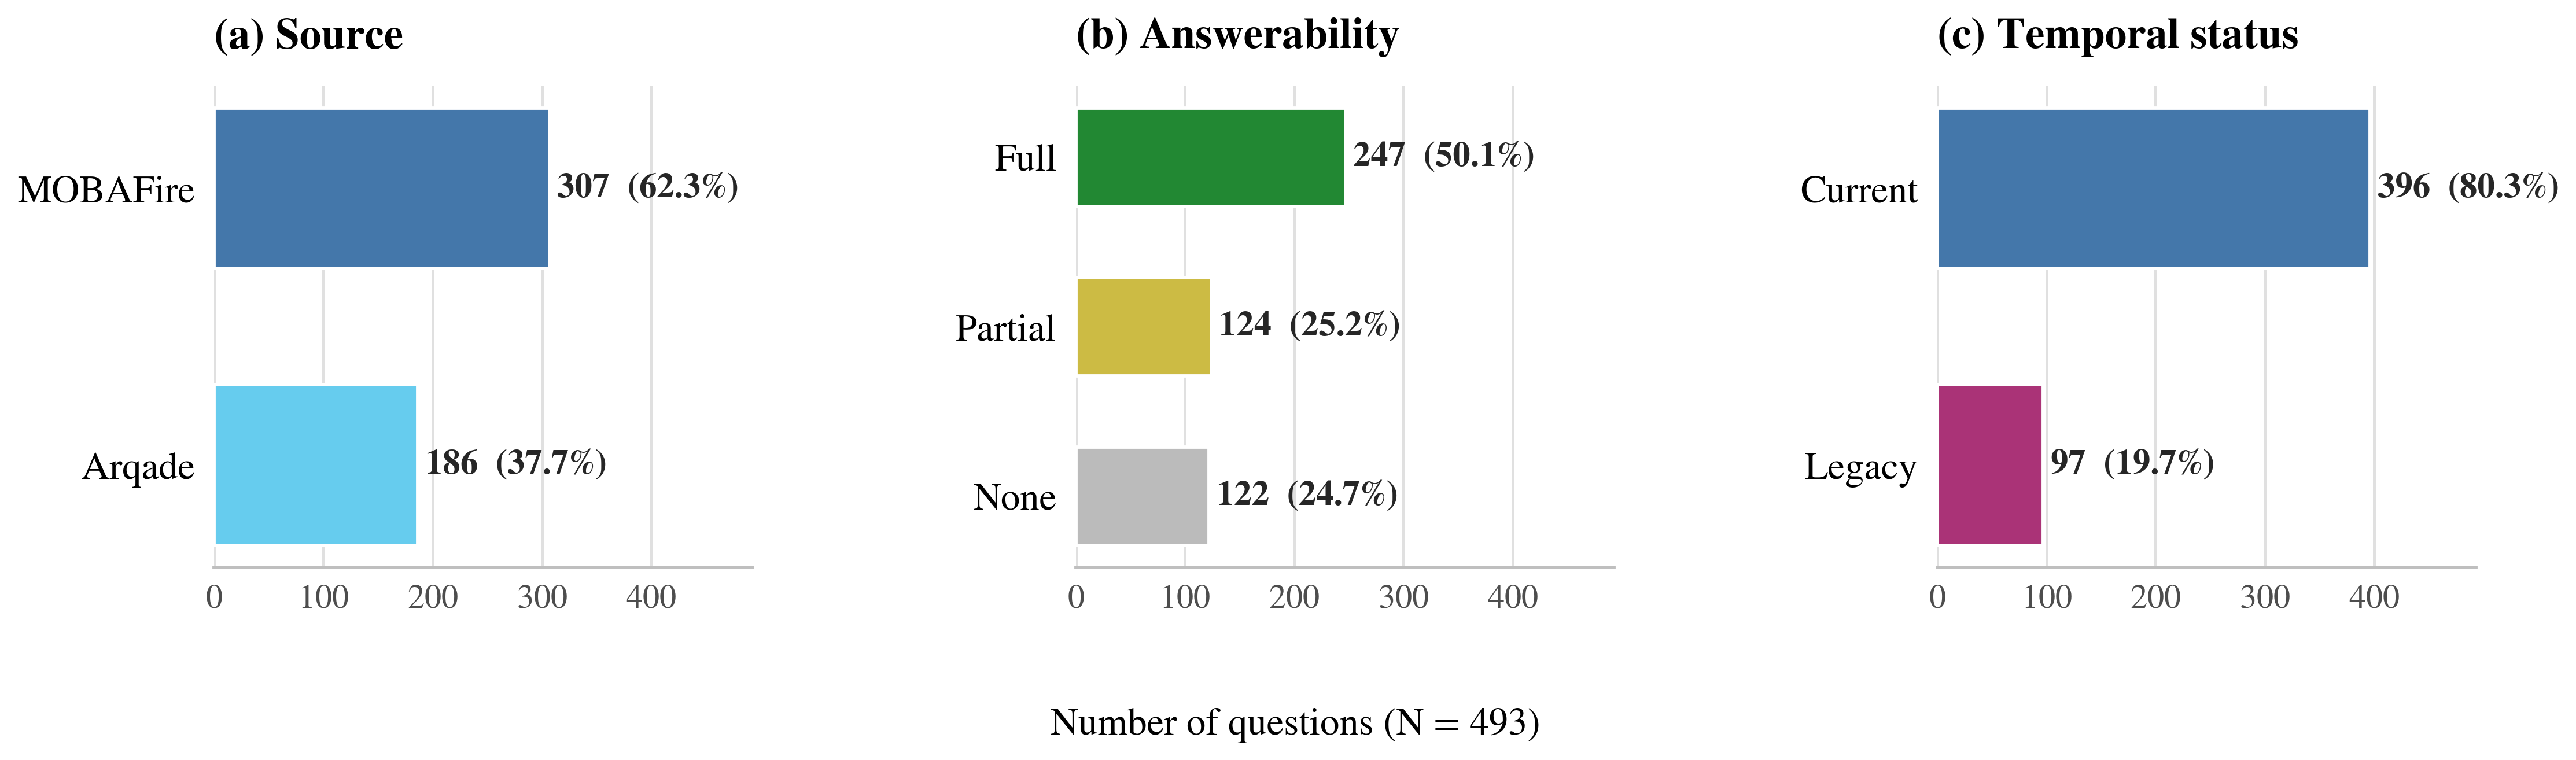

Saved PNG export to /home/gatv-projects/Desktop/project/knowledge_system_evaluation_v2/paper_v2_development


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(7.16, 2.35), sharex=True)
for ax, panel in zip(axes, panels):
    draw_panel(ax, panel, total_questions)

fig.supxlabel("Number of questions (N = 493)", x=0.52, y=0.055, fontsize=8)
fig.subplots_adjust(left=0.085, right=0.995, top=0.86, bottom=0.27, wspace=0.60)

output_dir = Path.cwd()
if output_dir.name != "paper_v2_development":
    output_dir = Path("knowledge_system_evaluation_v2/paper_v2_development")
output_dir.mkdir(parents=True, exist_ok=True)
output_stem = output_dir / "figure_1_evaluation_dataset_composition"

fig.savefig(output_stem.with_suffix(".png"), bbox_inches="tight", facecolor="white")

plt.show()
print(f"Saved PNG export to {output_dir.resolve()}")

# Figure 2 — Main Metric Heatmap Across Systems

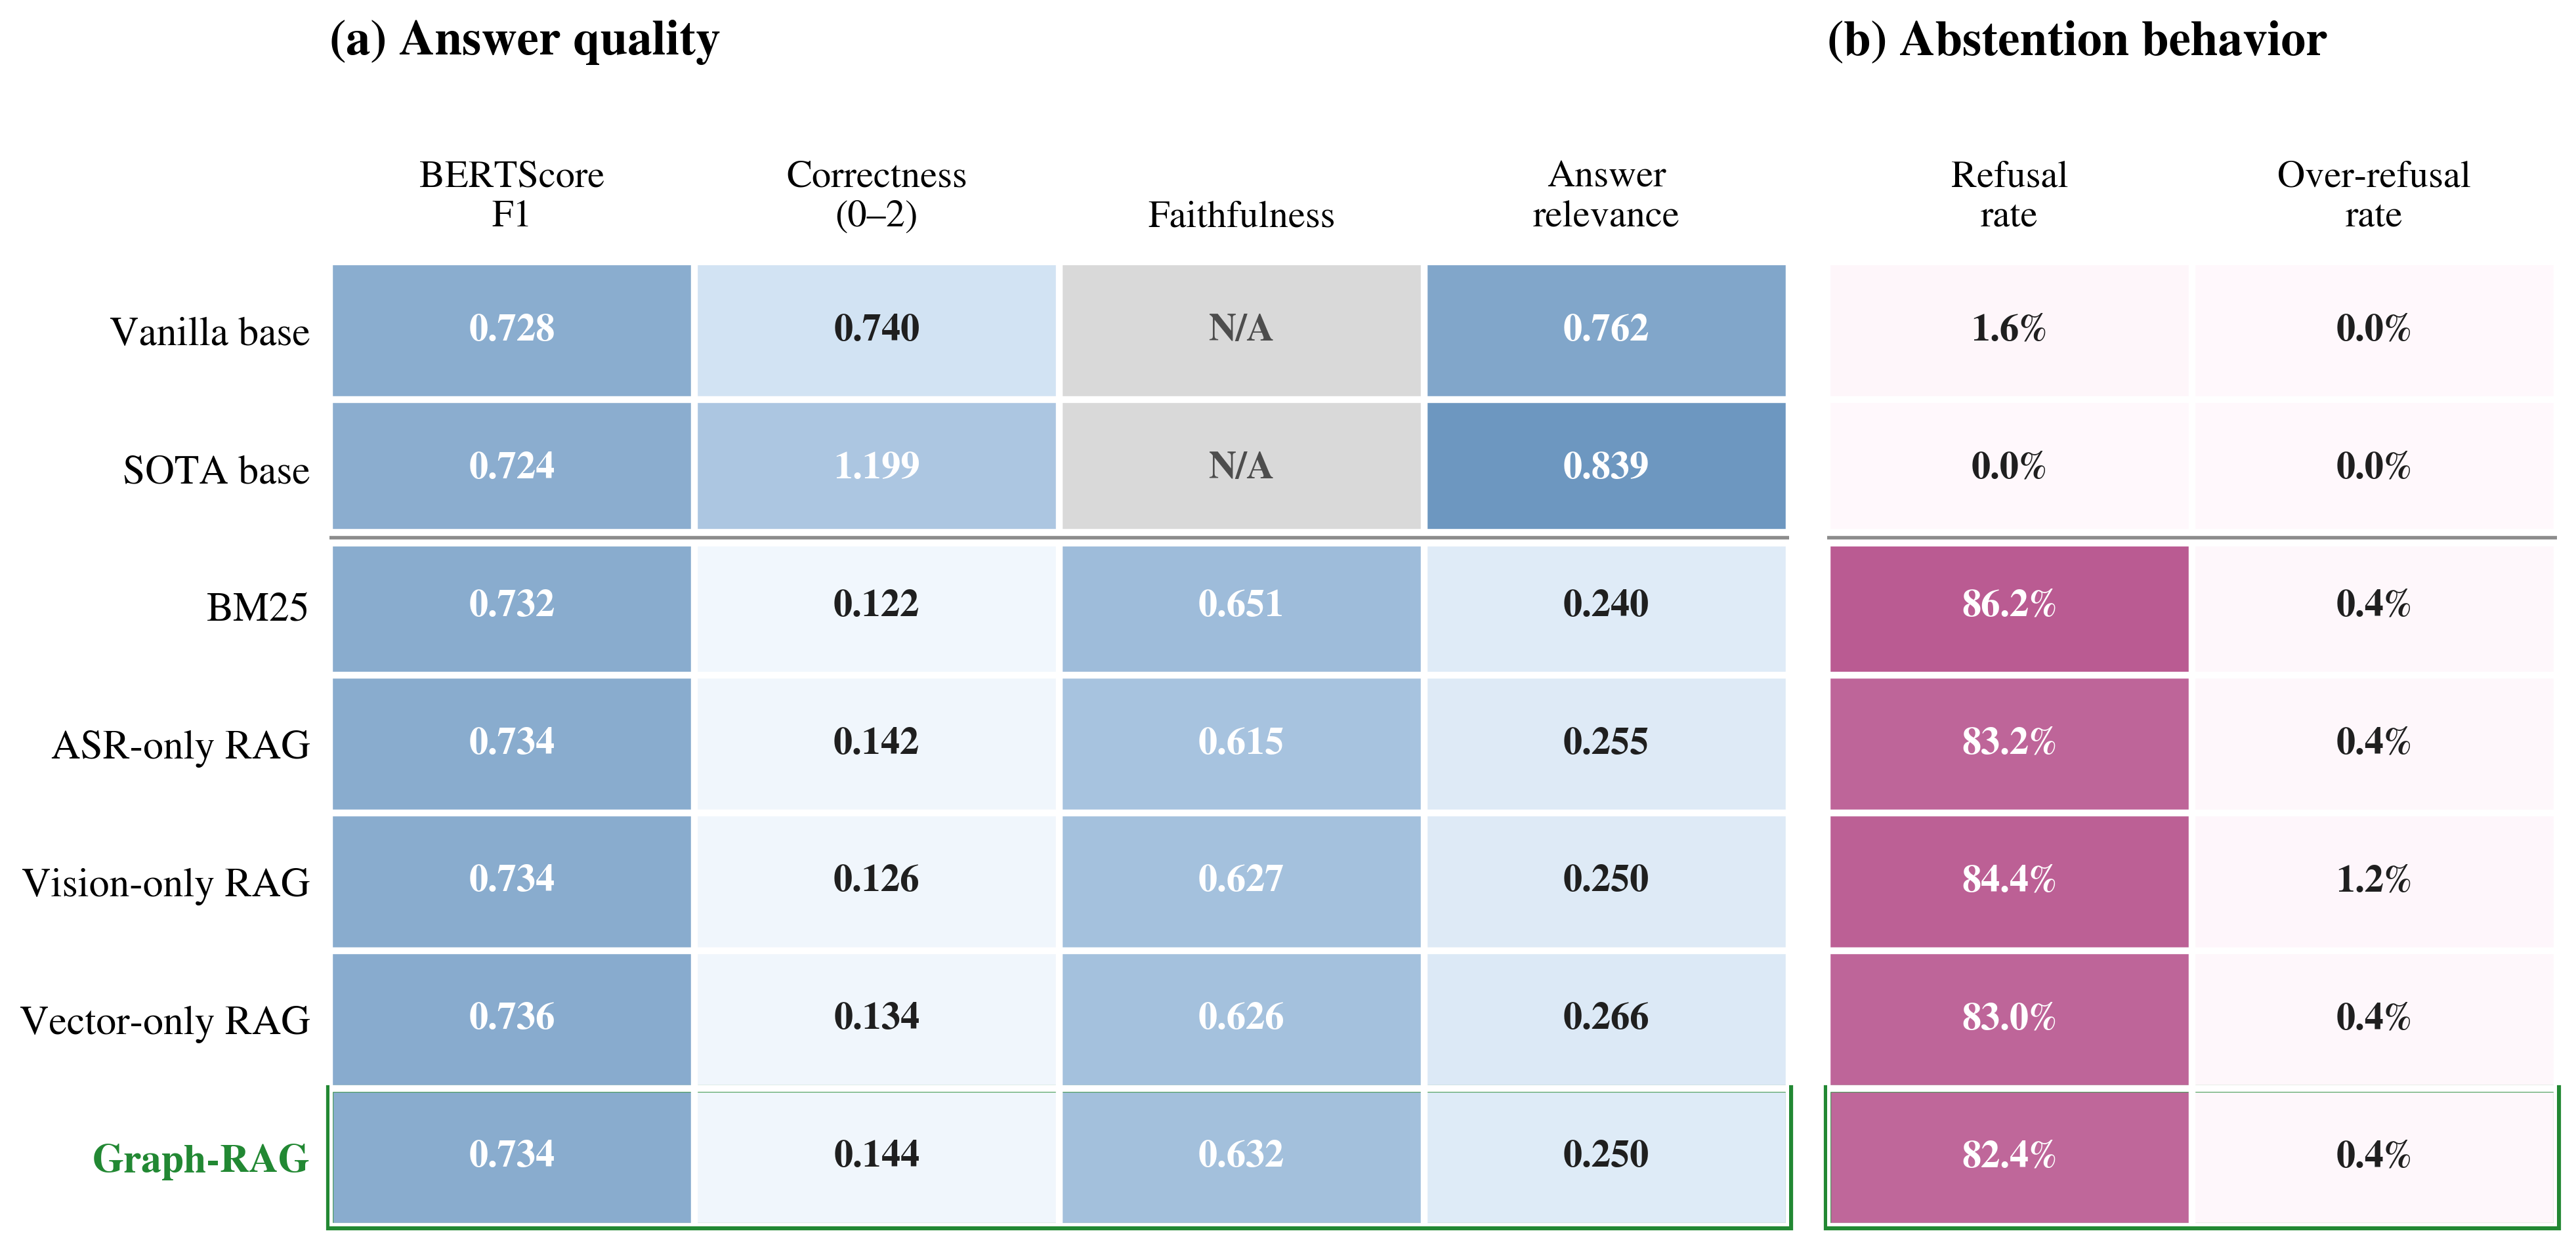

Loaded 493 evaluated questions from /home/gatv-projects/Desktop/project/knowledge_system_evaluation_v2/evaluated_datasets/community_qa_dataset_final_v2.json
Saved PNG export to /home/gatv-projects/Desktop/project/knowledge_system_evaluation_v2/paper_v2_development/figure_2_main_metric_heatmap.png


In [1]:
from pathlib import Path
import json

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
import numpy as np
import scienceplots

# SciencePlots styles recommended for IEEE figures; no-latex keeps execution portable.
plt.style.use(["science", "ieee", "no-latex", "bright"])
mpl.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.titleweight": "semibold",
    "xtick.labelsize": 7,
    "ytick.labelsize": 7.4,
    "savefig.dpi": 600,
})
BRIGHT = mpl.rcParams["axes.prop_cycle"].by_key()["color"]


def locate_evaluated_dataset() -> Path:
    relative_path = Path("knowledge_system_evaluation_v2/evaluated_datasets/community_qa_dataset_final_v2.json")
    candidates = [
        Path.cwd() / relative_path,
        Path.cwd().parent / "evaluated_datasets/community_qa_dataset_final_v2.json",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(f"Could not locate {relative_path}")


dataset_path = locate_evaluated_dataset()
with dataset_path.open(encoding="utf-8") as file:
    records = json.load(file)

systems = [
    ("vanilla_base", "Vanilla base"),
    ("sota_base", "SOTA base"),
    ("bm25", "BM25"),
    ("asr_only", "ASR-only RAG"),
    ("vision_only", "Vision-only RAG"),
    ("vector_only", "Vector-only RAG"),
    ("graph_rag", "Graph-RAG"),
]
metrics = [
    ("bertscore_f1", "BERTScore\nF1"),
    ("correctness_score", "Correctness\n(0–2)"),
    ("faithfulness", "Faithfulness"),
    ("relevance", "Answer\nrelevance"),
    ("is_refusal", "Refusal\nrate"),
    ("is_overrefusal", "Over-refusal\nrate"),
]

assert len(records) == 493
expected_systems = {key for key, _ in systems}
assert all(expected_systems.issubset(record["ablations"]) for record in records)

raw_values = np.full((len(systems), len(metrics)), np.nan, dtype=float)
for row_index, (system_key, _) in enumerate(systems):
    for column_index, (metric_key, _) in enumerate(metrics):
        observed = [
            record["ablations"][system_key].get(metric_key)
            for record in records
            if record["ablations"][system_key].get(metric_key) is not None
        ]
        if observed:
            raw_values[row_index, column_index] = np.mean([float(value) for value in observed])

# Faithfulness is undefined without retrieved evidence; all other cells are complete.
assert np.isnan(raw_values[:2, 2]).all()
assert np.isfinite(raw_values[2:, 2]).all()
assert np.isfinite(raw_values[:, [0, 1, 3, 4, 5]]).all()

# Color uses each metric's natural scale: [0, 1], except correctness [0, 2].
quality_raw = raw_values[:, :4]
quality_color = quality_raw.copy()
quality_color[:, 1] /= 2.0
behavior_raw = raw_values[:, 4:]

quality_cmap = LinearSegmentedColormap.from_list(
    "quality_heatmap", ["#F7FBFF", "#C6DBEF", BRIGHT[0]]
).with_extremes(bad="#D9D9D9")
behavior_cmap = LinearSegmentedColormap.from_list(
    "behavior_heatmap", ["#FFF8FC", "#E6C8DC", BRIGHT[5]]
)

fig = plt.figure(figsize=(7.16, 3.55), facecolor="white")
grid = fig.add_gridspec(1, 2, width_ratios=[4, 2], wspace=0.035)
quality_ax = fig.add_subplot(grid[0, 0])
behavior_ax = fig.add_subplot(grid[0, 1], sharey=quality_ax)

quality_ax.imshow(
    np.ma.masked_invalid(quality_color),
    cmap=quality_cmap,
    vmin=0,
    vmax=1,
    aspect="auto",
    interpolation="nearest",
)
behavior_ax.imshow(
    behavior_raw,
    cmap=behavior_cmap,
    vmin=0,
    vmax=1,
    aspect="auto",
    interpolation="nearest",
)

quality_labels = [label for _, label in metrics[:4]]
behavior_labels = [label for _, label in metrics[4:]]
system_labels = [label for _, label in systems]

for ax, column_labels in (
    (quality_ax, quality_labels),
    (behavior_ax, behavior_labels),
):
    ax.set_xticks(range(len(column_labels)), column_labels)
    ax.xaxis.tick_top()
    ax.tick_params(axis="x", which="both", top=False, bottom=False, labeltop=True, labelbottom=False, pad=5)
    ax.tick_params(axis="y", which="both", left=False, right=False)
    ax.set_xticks(np.arange(-0.5, len(column_labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(systems), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.25)
    for spine in ax.spines.values():
        spine.set_visible(False)
    # Separate no-context baselines (top) from retrieval-based systems (bottom).
    ax.axhline(1.5, color="white", linewidth=3.2)
    ax.axhline(1.5, color="#8C8C8C", linewidth=0.65)

quality_ax.set_yticks(range(len(system_labels)), system_labels)
behavior_ax.tick_params(labelleft=False)
quality_ax.set_title("(a) Answer quality", loc="left", pad=38)
behavior_ax.set_title("(b) Abstention behavior", loc="left", pad=38)

for row in range(len(systems)):
    for column in range(4):
        value = quality_raw[row, column]
        if np.isnan(value):
            label = "N/A"
            text_color = "#4D4D4D"
        else:
            label = f"{value:.3f}"
            text_color = "white" if quality_color[row, column] >= 0.58 else "#1F1F1F"
        quality_ax.text(
            column,
            row,
            label,
            ha="center",
            va="center",
            color=text_color,
            fontsize=7,
            fontweight="semibold",
        )

for row in range(len(systems)):
    for column in range(2):
        value = behavior_raw[row, column]
        behavior_ax.text(
            column,
            row,
            f"{100 * value:.1f}%",
            ha="center",
            va="center",
            color="white" if value >= 0.58 else "#1F1F1F",
            fontsize=7,
            fontweight="semibold",
        )

# Consistent accent for the proposed full system.
for ax, width in ((quality_ax, 4), (behavior_ax, 2)):
    ax.add_patch(
        Rectangle(
            (-0.5, 5.5),
            width,
            1,
            fill=False,
            edgecolor=BRIGHT[2],
            linewidth=1.35,
            clip_on=False,
        )
    )
graph_label = quality_ax.get_yticklabels()[-1]
graph_label.set_color(BRIGHT[2])
graph_label.set_fontweight("bold")

# fig.text(
#     0.205,
#     0.035,
#     "No-context baselines above separator; retrieval systems below. "
#     "Darker shade indicates a larger raw value; gray denotes not applicable.",
#     ha="left",
#     va="center",
#     fontsize=6.6,
#     color="#4D4D4D",
# )
fig.subplots_adjust(left=0.205, right=0.995, top=0.79, bottom=0.10)

output_dir = Path.cwd()
if output_dir.name != "paper_v2_development":
    output_dir = Path("knowledge_system_evaluation_v2/paper_v2_development")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "figure_2_main_metric_heatmap.png"
fig.savefig(output_path, dpi=600, bbox_inches="tight", facecolor="white", transparent=False)

plt.show()
print(f"Loaded {len(records)} evaluated questions from {dataset_path}")
print(f"Saved PNG export to {output_path.resolve()}")

# Figure 3 — Correctness Versus Refusal Trade-off

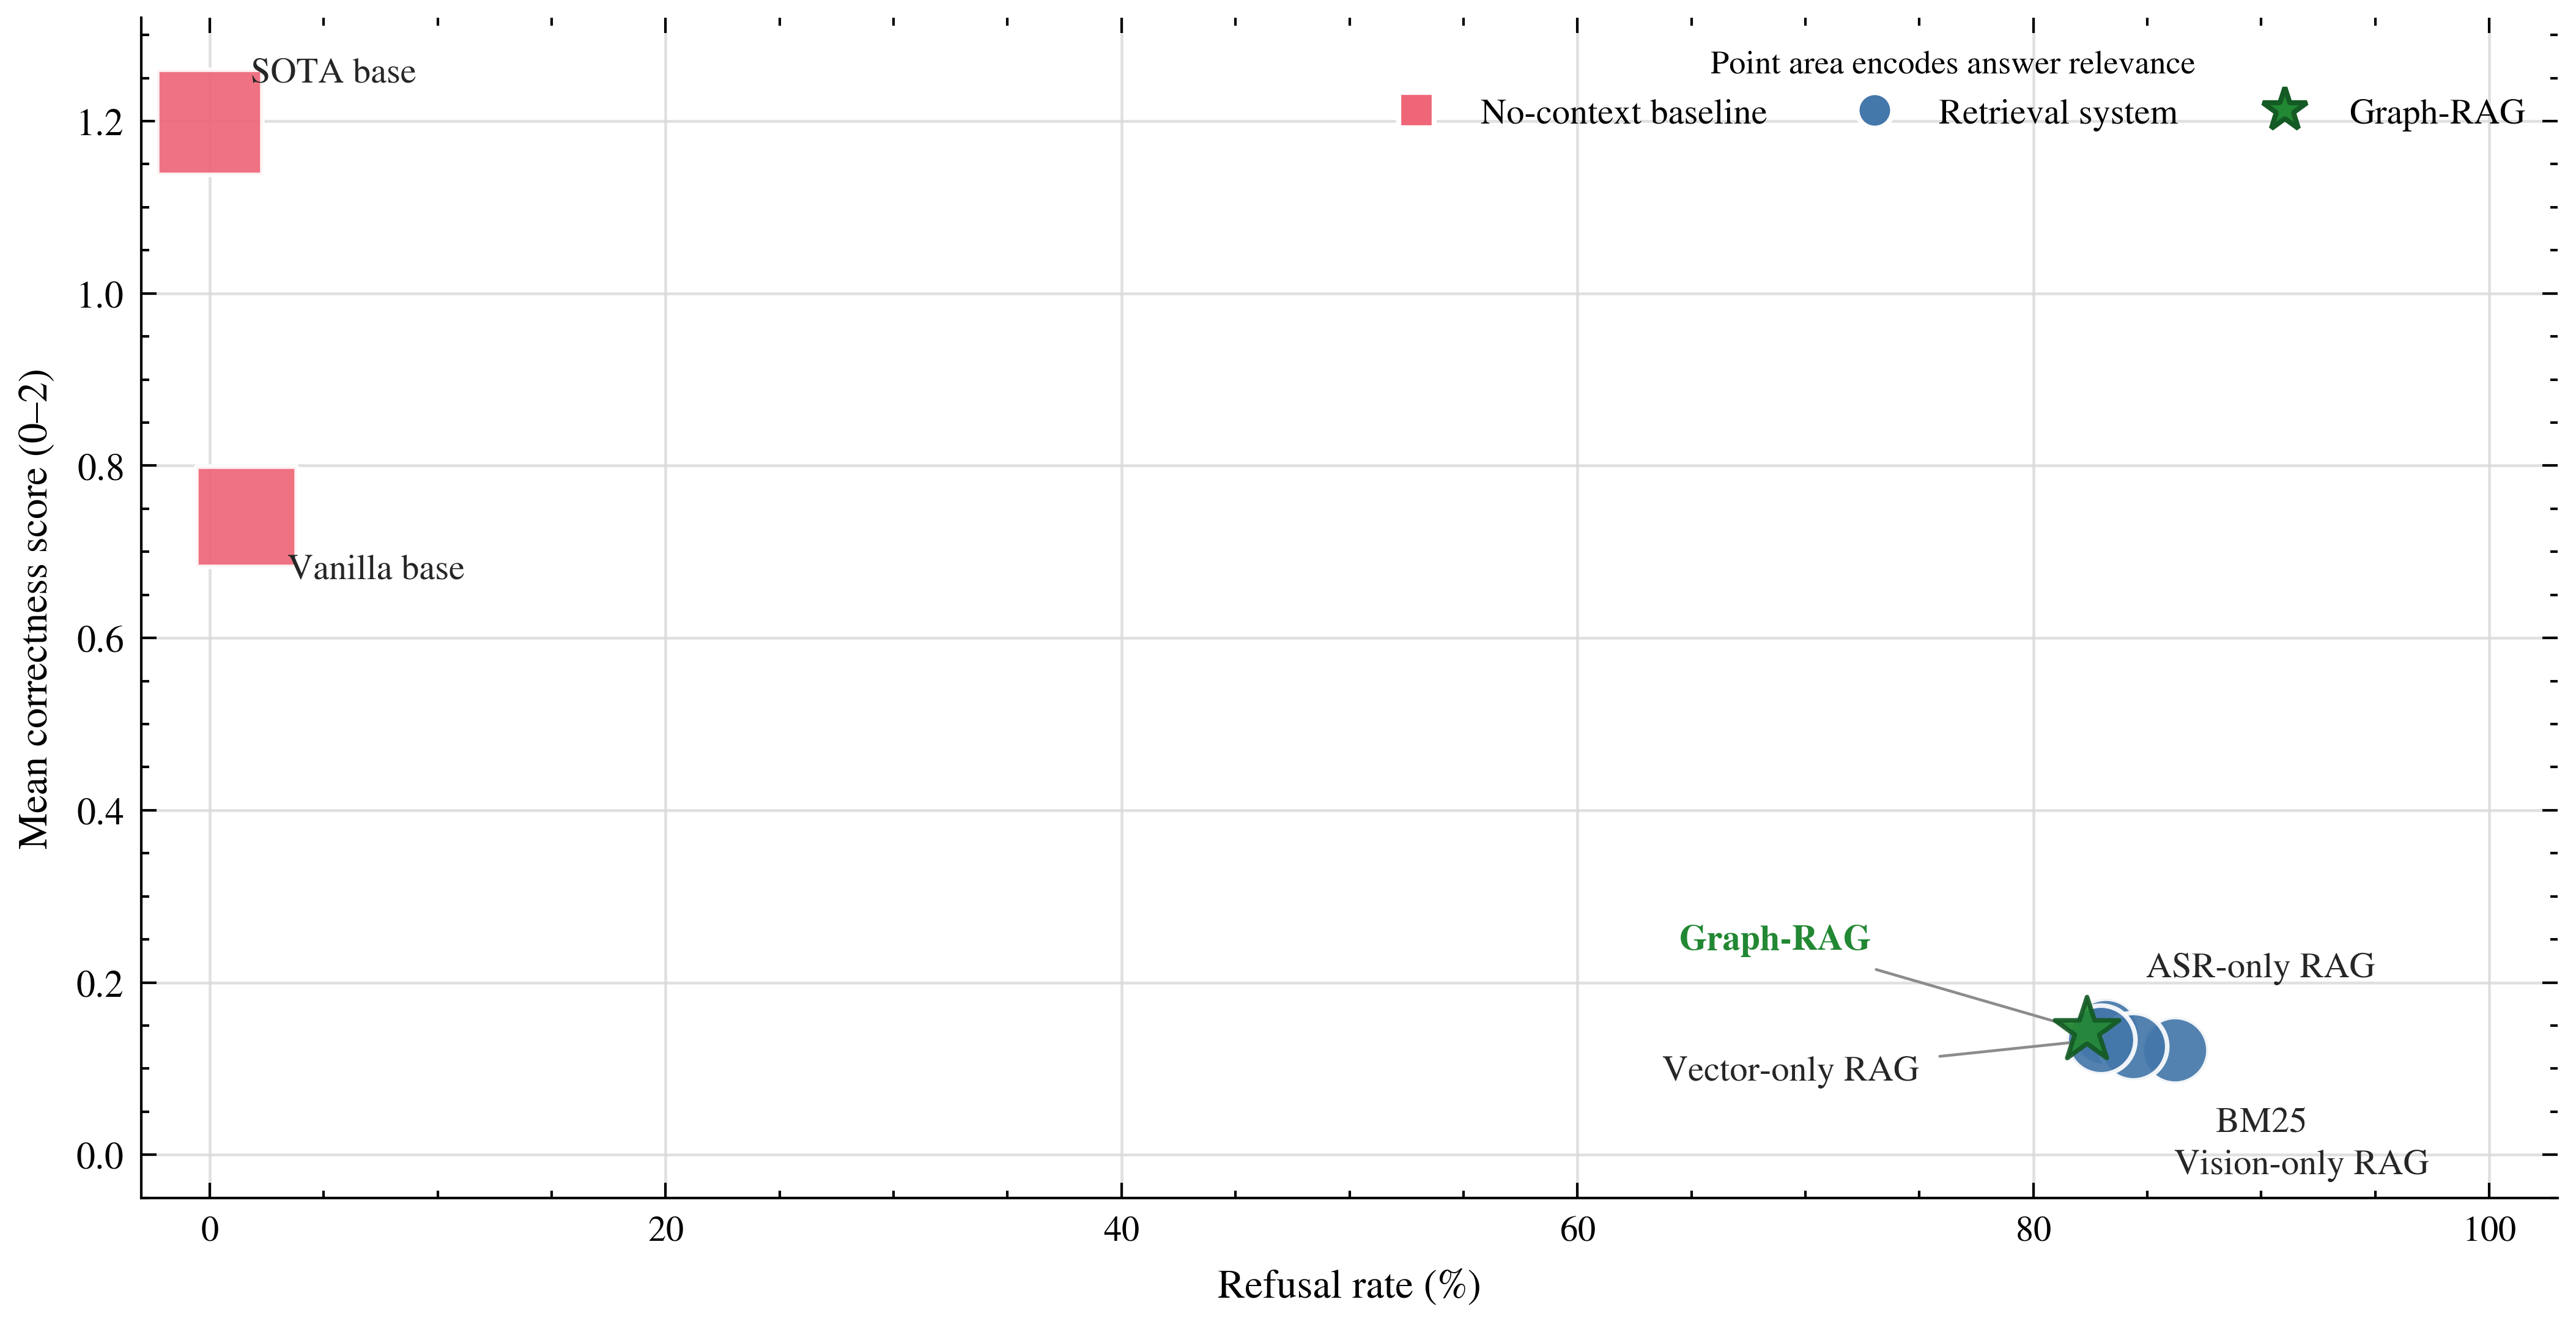

Saved PNG export to /home/gatv-projects/Desktop/project/knowledge_system_evaluation_v2/paper_v2_development/figure_3_correctness_vs_refusal_tradeoff.png


In [4]:
from matplotlib.lines import Line2D

system_index = {key: index for index, (key, _) in enumerate(systems)}
label_offsets = {
    "vanilla_base": (8, -12),
    "sota_base": (8, 8),
    "bm25": (8, -16),
    "asr_only": (8, 11),
    "vision_only": (8, -25),
    "vector_only": (-86, -8),
    "graph_rag": (-80, 16),
}

fig, ax = plt.subplots(figsize=(7.16, 3.75), facecolor="white")
for key, label in systems:
    row = system_index[key]
    refusal = 100 * raw_values[row, 4]
    correctness = raw_values[row, 1]
    relevance = raw_values[row, 3]
    if key == "graph_rag":
        color, marker, edge, zorder = BRIGHT[2], "*", "#145A24", 4
    elif key in {"vanilla_base", "sota_base"}:
        color, marker, edge, zorder = BRIGHT[1], "s", "white", 3
    else:
        color, marker, edge, zorder = BRIGHT[0], "o", "white", 3
    ax.scatter(
        refusal,
        correctness,
        s=70 + 420 * relevance,
        color=color,
        marker=marker,
        edgecolor=edge,
        linewidth=0.9,
        alpha=0.92,
        zorder=zorder,
    )
    ax.annotate(
        label,
        (refusal, correctness),
        xytext=label_offsets[key],
        textcoords="offset points",
        fontsize=7,
        fontweight="bold" if key == "graph_rag" else "normal",
        color=BRIGHT[2] if key == "graph_rag" else "#262626",
        arrowprops=dict(arrowstyle="-", color="#8C8C8C", lw=0.55) if abs(label_offsets[key][0]) > 30 else None,
    )

ax.set_xlim(-3, 103)
ax.set_ylim(-0.05, 1.32)
ax.set_xlabel("Refusal rate (%)")
ax.set_ylabel("Mean correctness score (0–2)")
ax.grid(color="#D9D9D9", linewidth=0.55, alpha=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(
    handles=[
        Line2D([0], [0], marker="s", color="none", markerfacecolor=BRIGHT[1], markeredgecolor="white", markersize=7, label="No-context baseline"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor=BRIGHT[0], markeredgecolor="white", markersize=7, label="Retrieval system"),
        Line2D([0], [0], marker="*", color="none", markerfacecolor=BRIGHT[2], markeredgecolor="#145A24", markersize=9, label="Graph-RAG"),
    ],
    loc="upper right",
    frameon=False,
    ncol=3,
    fontsize=7,
    title="Point area encodes answer relevance",
    title_fontsize=6.5,
)
fig.tight_layout()
output_path = output_dir / "figure_3_correctness_vs_refusal_tradeoff.png"
fig.savefig(output_path, dpi=600, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print(f"Saved PNG export to {output_path.resolve()}")

# Figure 4 — Graph-RAG Versus Vector-only by Answerability Stratum

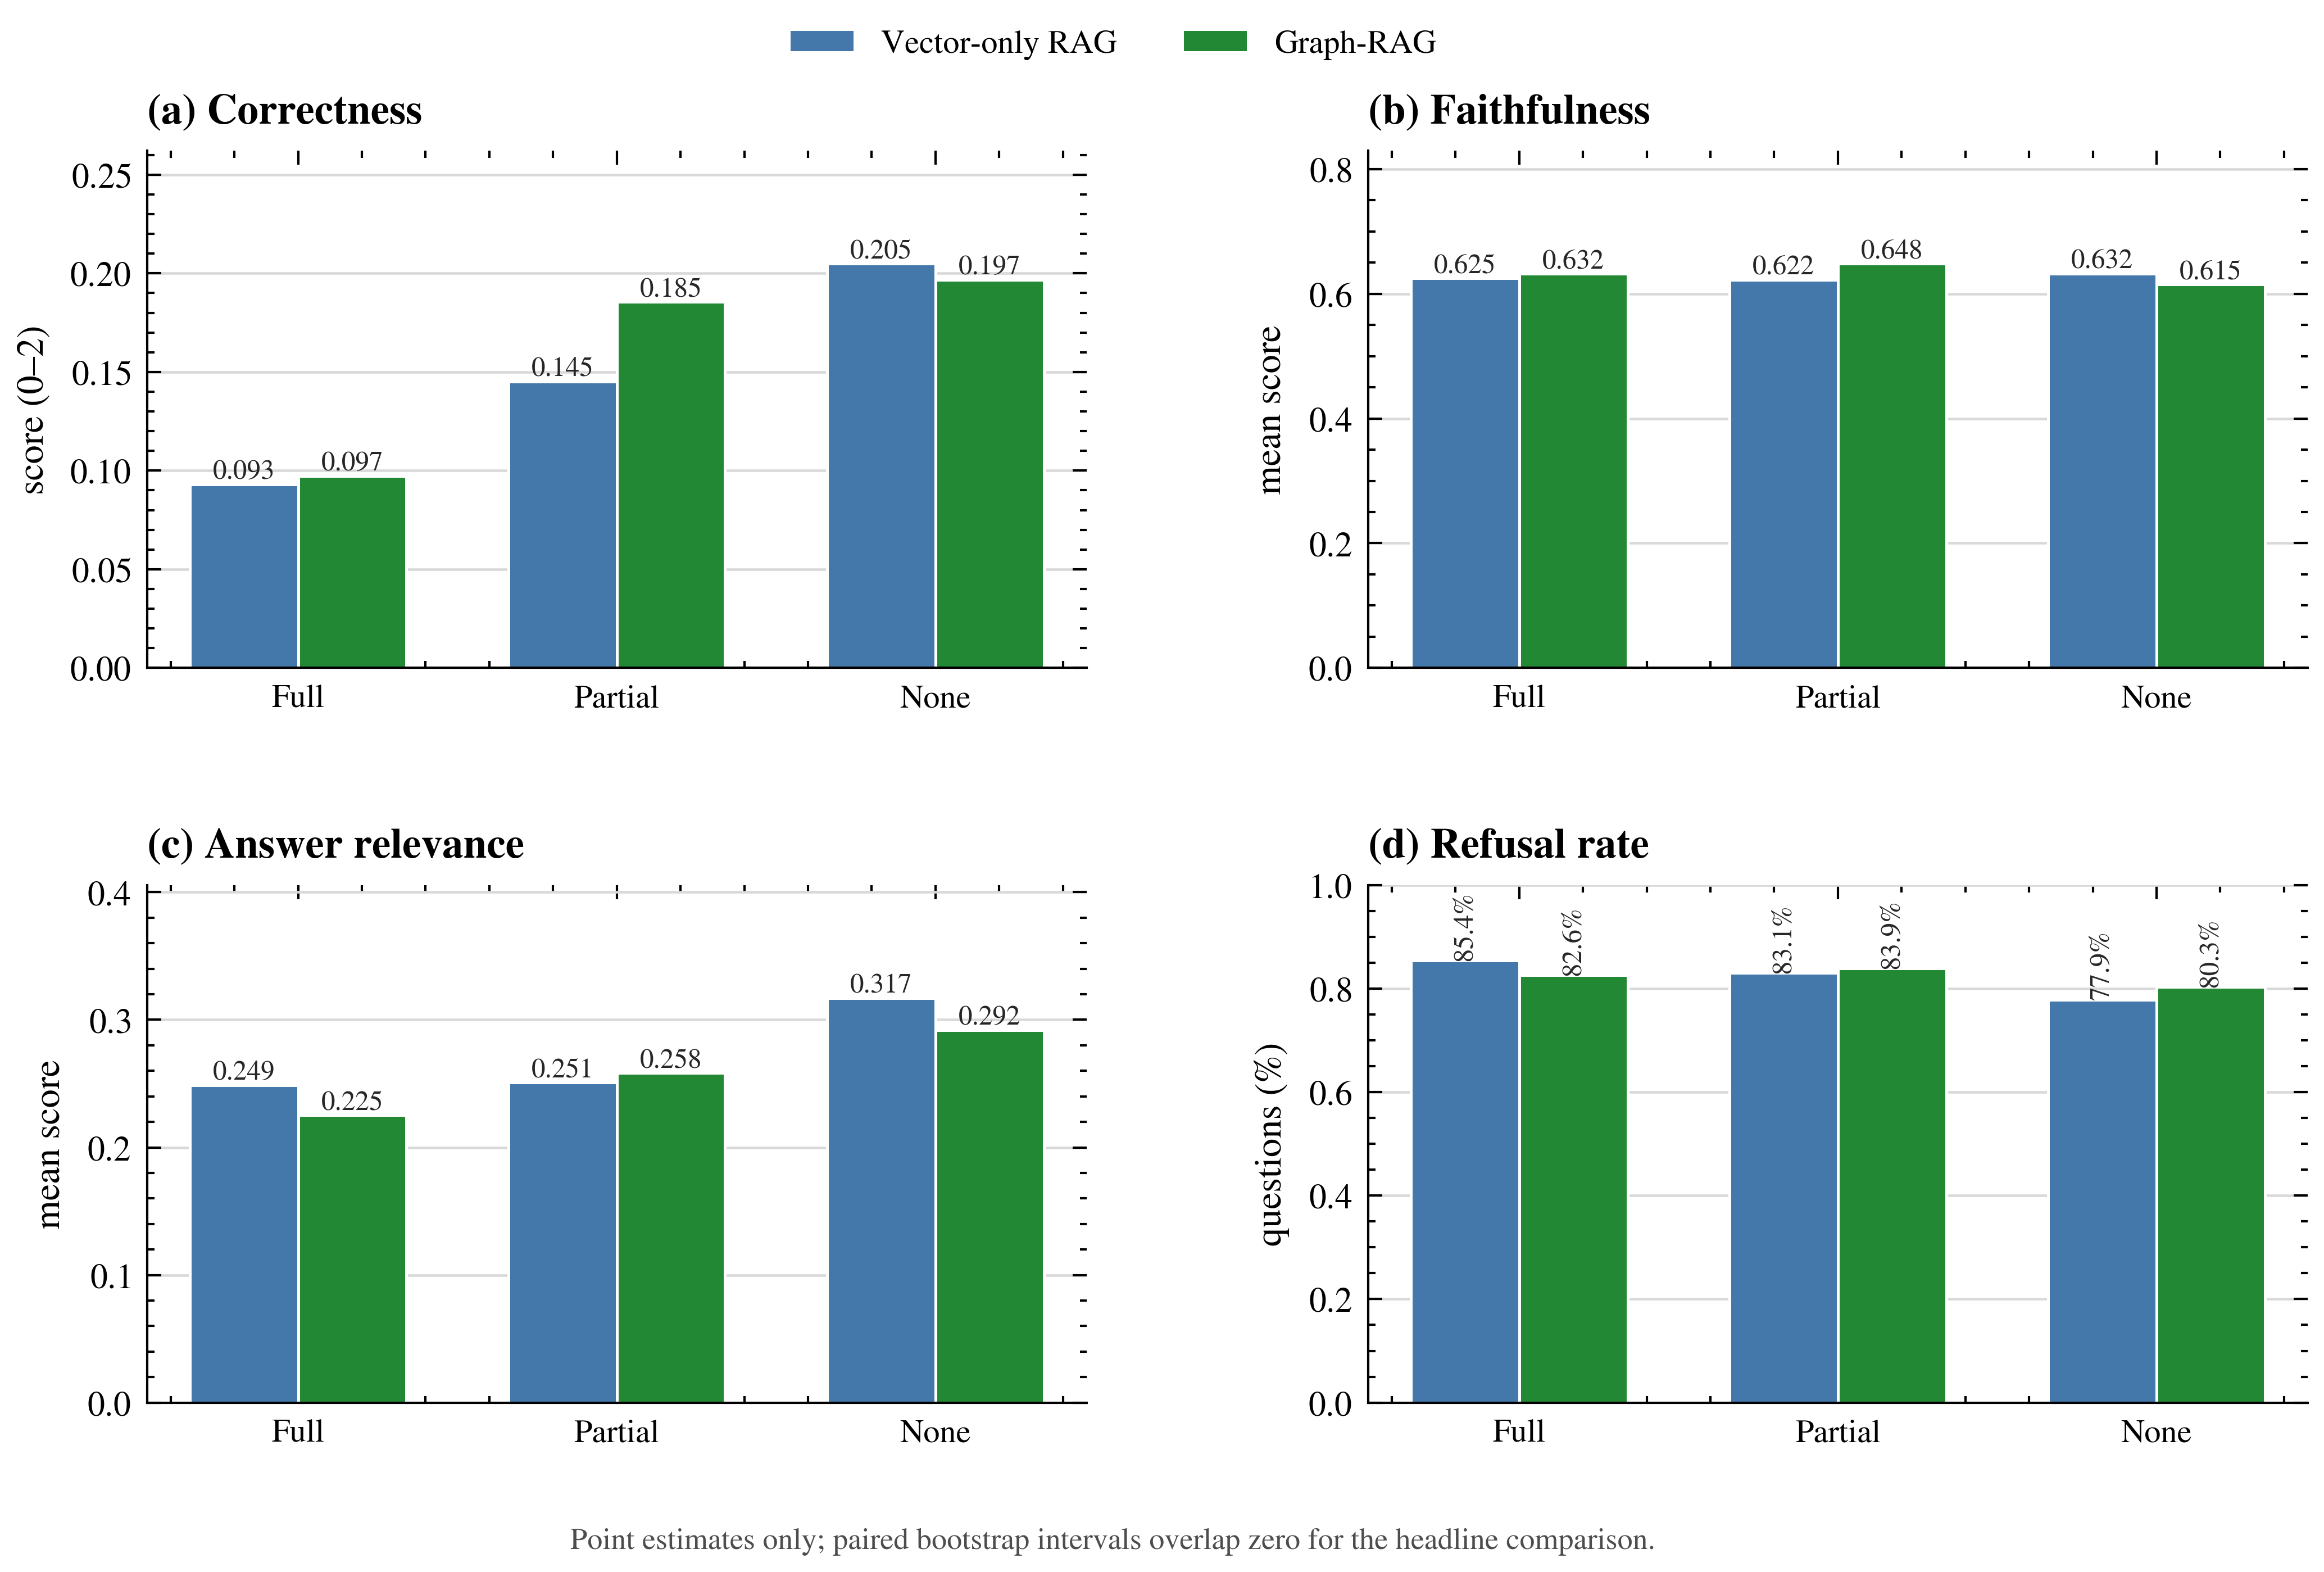

Saved PNG export to /home/gatv-projects/Desktop/project/knowledge_system_evaluation_v2/paper_v2_development/figure_4_graph_vs_vector_by_answerability.png


In [5]:
strata = ["Full", "Partial", "None"]
comparison_systems = [("vector_only", "Vector-only RAG", BRIGHT[0]), ("graph_rag", "Graph-RAG", BRIGHT[2])]
metric_specs = [
    ("correctness_score", "(a) Correctness", "score (0–2)", False),
    ("faithfulness", "(b) Faithfulness", "mean score", False),
    ("relevance", "(c) Answer relevance", "mean score", False),
    ("is_refusal", "(d) Refusal rate", "questions (%)", True),
]


def stratum_mean(system_key, metric_key, stratum):
    values = [
        float(record["ablations"][system_key][metric_key])
        for record in records
        if record["answerability_status"] == stratum
        and record["ablations"][system_key][metric_key] is not None
    ]
    return float(np.mean(values))


fig, axes = plt.subplots(2, 2, figsize=(7.16, 4.7), facecolor="white")
bar_width = 0.34
x = np.arange(len(strata))
for ax, (metric_key, title, ylabel, percentage) in zip(axes.flat, metric_specs):
    plotted = []
    for offset, (system_key, system_label, color) in zip((-bar_width / 2, bar_width / 2), comparison_systems):
        values = [stratum_mean(system_key, metric_key, stratum) for stratum in strata]
        plotted.extend(values)
        bars = ax.bar(x + offset, values, width=bar_width, color=color, label=system_label, edgecolor="white", linewidth=0.6)
        for bar, value in zip(bars, values):
            label = f"{100 * value:.1f}%" if percentage else f"{value:.3f}"
            ax.text(bar.get_x() + bar.get_width() / 2, value, label, ha="center", va="bottom", fontsize=5.9, rotation=90 if percentage else 0, color="#262626")
    ax.set_title(title, loc="left", pad=6)
    ax.set_xticks(x, strata)
    ax.set_ylabel(ylabel)
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#D9D9D9", linewidth=0.55)
    ax.spines[["top", "right"]].set_visible(False)
    upper = 1.0 if percentage else max(plotted) * 1.28
    ax.set_ylim(0, upper)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.995), fontsize=7)
fig.text(0.5, 0.018, "Point estimates only; paired bootstrap intervals overlap zero for the headline comparison.", ha="center", fontsize=6.5, color="#4D4D4D")
fig.subplots_adjust(left=0.10, right=0.995, top=0.90, bottom=0.11, hspace=0.42, wspace=0.30)
output_path = output_dir / "figure_4_graph_vs_vector_by_answerability.png"
fig.savefig(output_path, dpi=600, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print(f"Saved PNG export to {output_path.resolve()}")

# Figure 5 — Graph-RAG Minus Vector-only Delta Plot

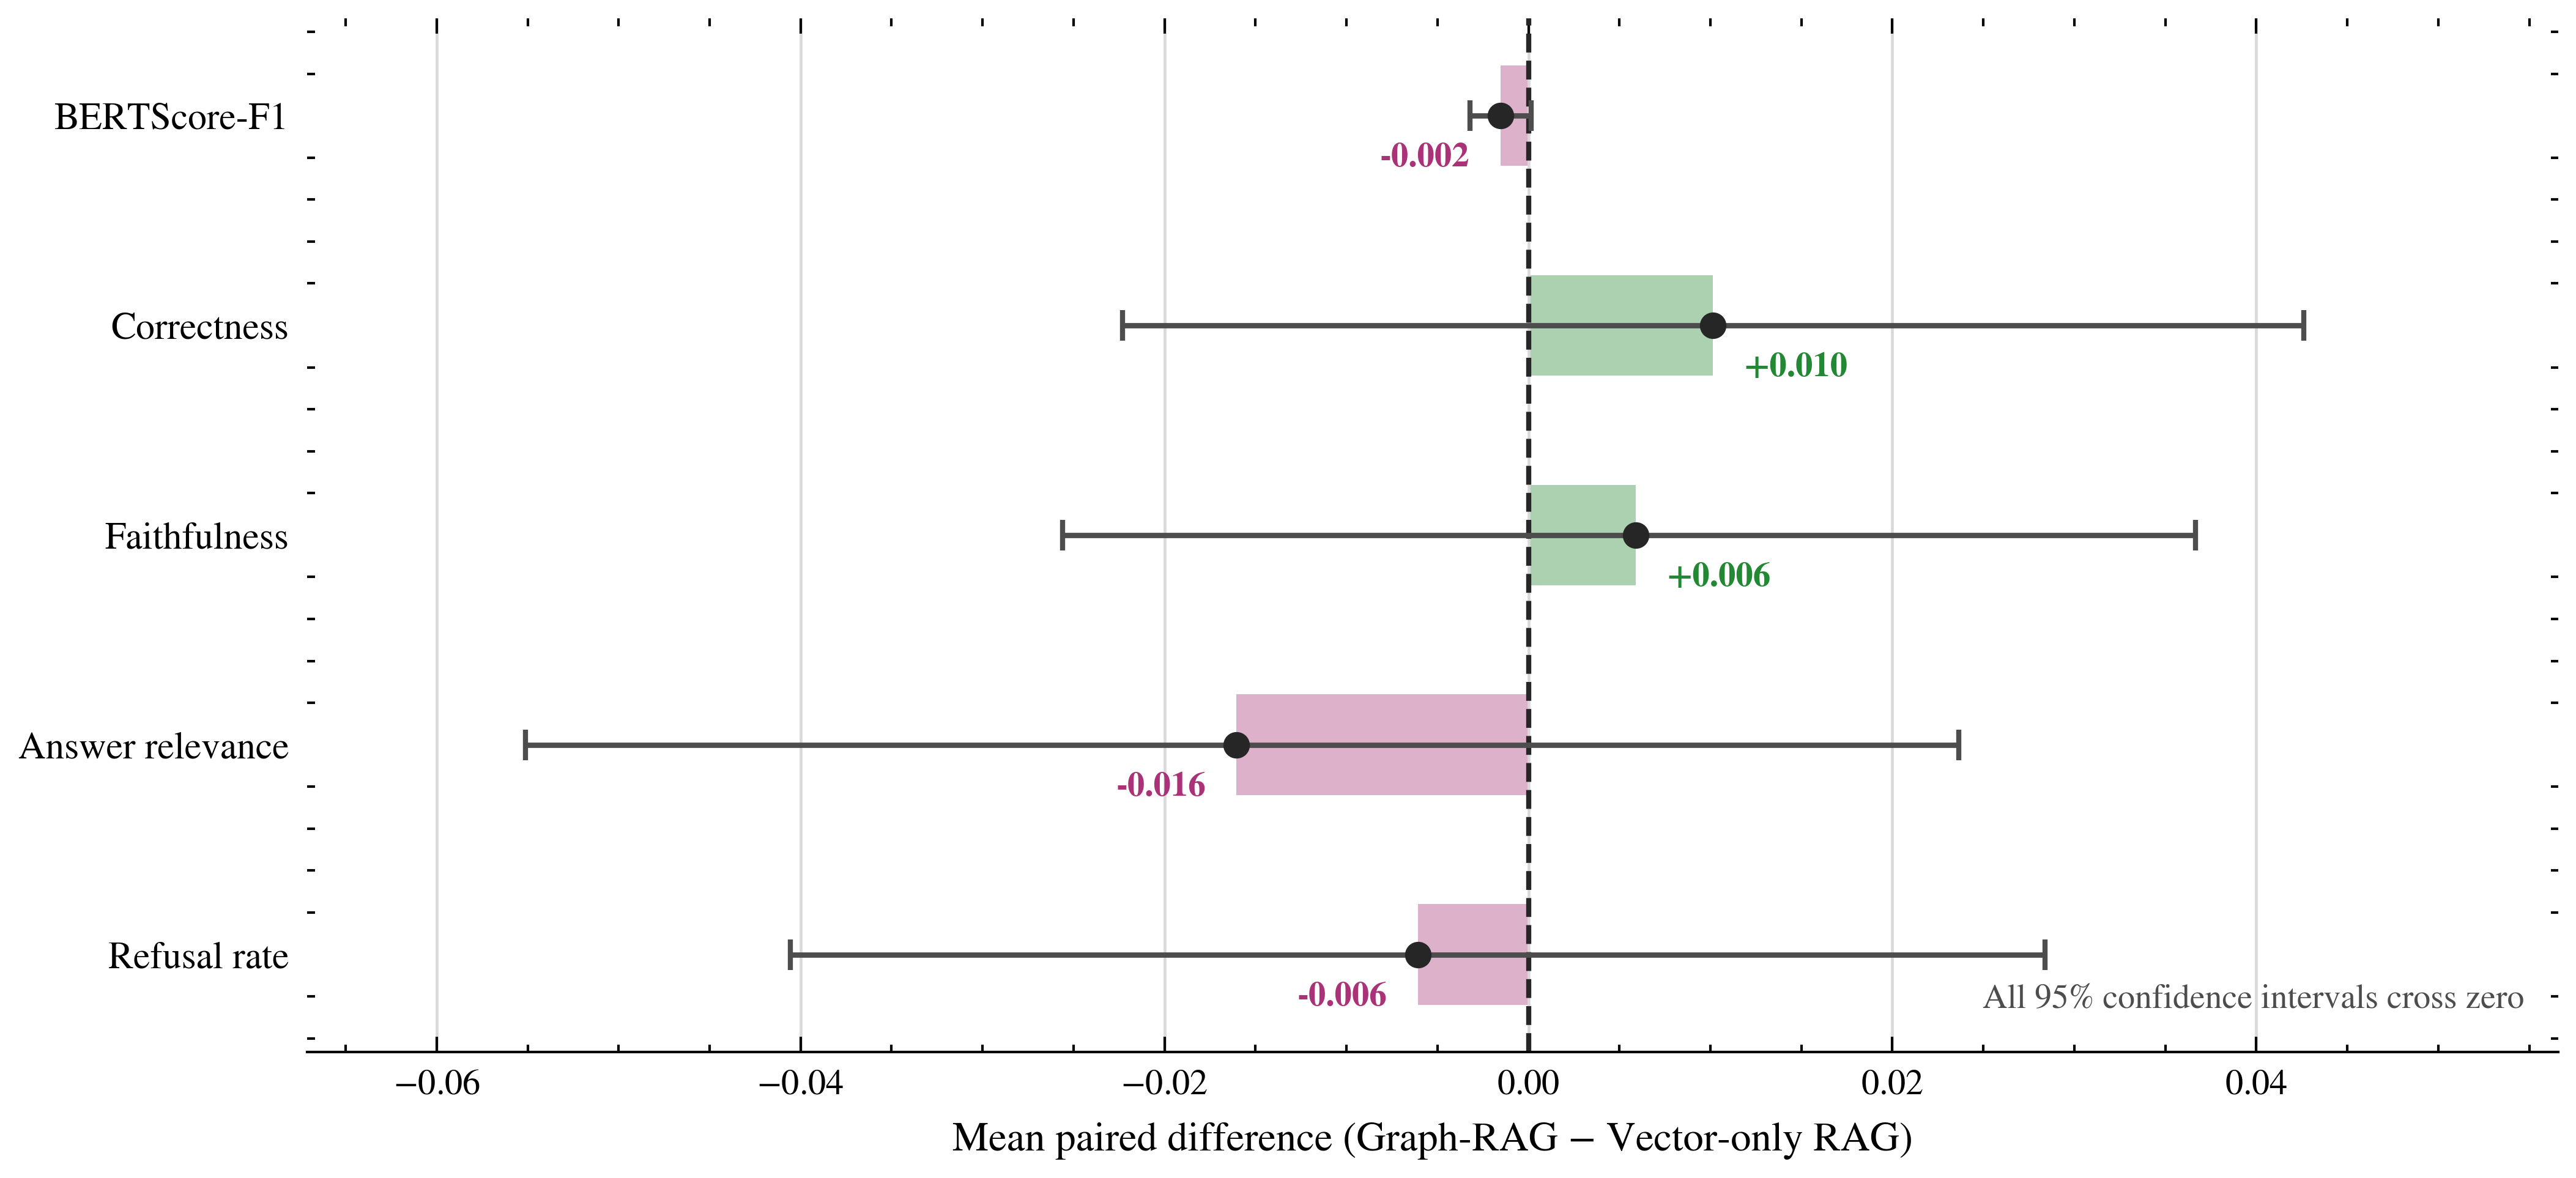

Loaded completed bootstrap results from /home/gatv-projects/Desktop/project/knowledge_system_evaluation_v2/phase6_analysis/bootstrap_graph_vs_vector.json
Saved PNG export to /home/gatv-projects/Desktop/project/knowledge_system_evaluation_v2/paper_v2_development/figure_5_graph_minus_vector_delta_ci.png


In [6]:
bootstrap_path = dataset_path.parents[1] / "phase6_analysis/bootstrap_graph_vs_vector.json"
with bootstrap_path.open(encoding="utf-8") as file:
    bootstrap_rows = json.load(file)

metric_order = ["bertscore_f1", "correctness_score", "faithfulness", "relevance", "refusal_rate"]
metric_labels = {
    "bertscore_f1": "BERTScore-F1",
    "correctness_score": "Correctness",
    "faithfulness": "Faithfulness",
    "relevance": "Answer relevance",
    "refusal_rate": "Refusal rate",
}
aggregate = {row["metric"]: row for row in bootstrap_rows if row["slice"] == "all"}
assert all(metric in aggregate for metric in metric_order)
means = np.array([aggregate[metric]["mean_diff"] for metric in metric_order])
lows = np.array([aggregate[metric]["ci_low"] for metric in metric_order])
highs = np.array([aggregate[metric]["ci_high"] for metric in metric_order])
assert np.all(lows <= 0) and np.all(highs >= 0)

y = np.arange(len(metric_order))
colors = [BRIGHT[2] if value >= 0 else BRIGHT[5] for value in means]
fig, ax = plt.subplots(figsize=(7.16, 3.35), facecolor="white")
ax.barh(y, means, color=colors, alpha=0.38, height=0.48, edgecolor="none")
ax.errorbar(
    means,
    y,
    xerr=np.vstack([means - lows, highs - means]),
    fmt="o",
    color="#262626",
    ecolor="#4D4D4D",
    elinewidth=1.05,
    capsize=3,
    markersize=4.2,
    zorder=3,
)
ax.axvline(0, color="#262626", linewidth=1.0, linestyle="--", zorder=2)
ax.set_yticks(y, [metric_labels[metric] for metric in metric_order])
ax.invert_yaxis()
ax.set_xlabel("Mean paired difference (Graph-RAG − Vector-only RAG)")
ax.set_xlim(min(lows) - 0.012, max(highs) + 0.014)
ax.grid(axis="x", color="#D9D9D9", linewidth=0.55)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
for row, value in enumerate(means):
    ax.annotate(f"{value:+.3f}", (value, row), xytext=(6 if value >= 0 else -6, -10), textcoords="offset points", ha="left" if value >= 0 else "right", fontsize=6.8, fontweight="semibold", color=colors[row])
ax.text(0.985, 0.035, "All 95% confidence intervals cross zero", transform=ax.transAxes, ha="right", va="bottom", fontsize=6.7, color="#4D4D4D")
fig.tight_layout()
output_path = output_dir / "figure_5_graph_minus_vector_delta_ci.png"
fig.savefig(output_path, dpi=600, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print(f"Loaded completed bootstrap results from {bootstrap_path}")
print(f"Saved PNG export to {output_path.resolve()}")

# Figure 6 — Correctness Score Distribution

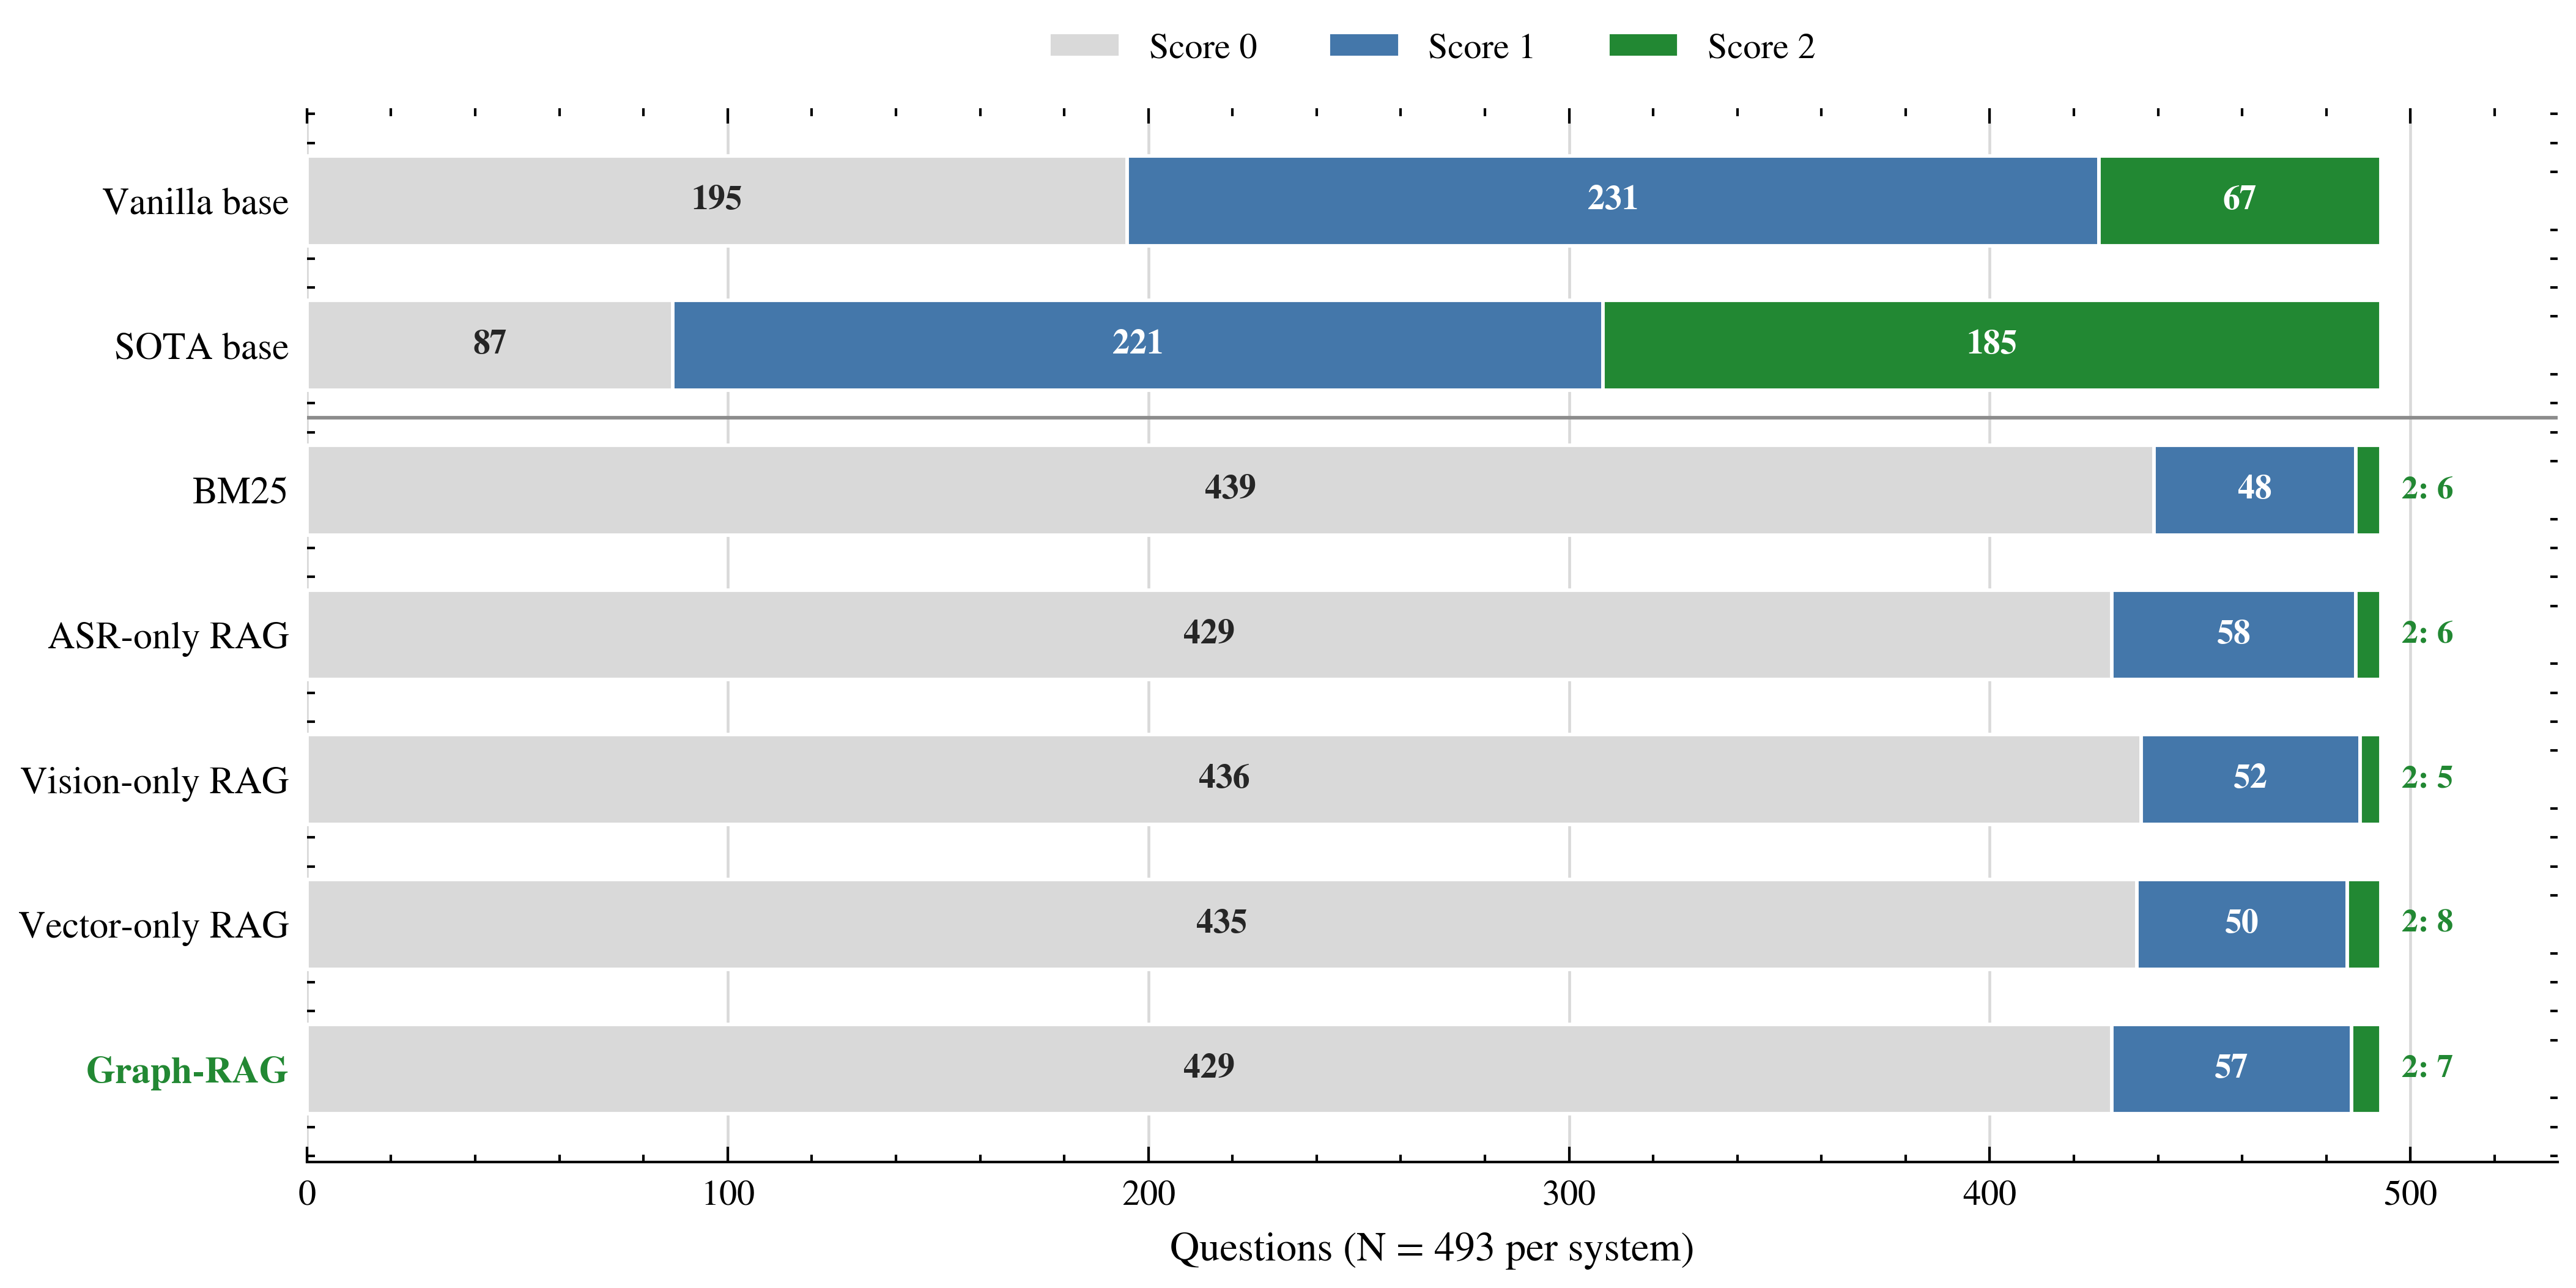

Saved PNG export to /home/gatv-projects/Desktop/project/knowledge_system_evaluation_v2/paper_v2_development/figure_6_correctness_score_distribution.png


In [7]:
from collections import Counter

score_systems = [
    ("vanilla_base", "Vanilla base"),
    ("sota_base", "SOTA base"),
    ("bm25", "BM25"),
    ("asr_only", "ASR-only RAG"),
    ("vision_only", "Vision-only RAG"),
    ("vector_only", "Vector-only RAG"),
    ("graph_rag", "Graph-RAG"),
]
score_counts = []
for system_key, _ in score_systems:
    counts = Counter(int(record["ablations"][system_key]["correctness_score"]) for record in records)
    score_counts.append([counts[0], counts[1], counts[2]])
score_counts = np.asarray(score_counts)
assert np.all(score_counts.sum(axis=1) == 493)

fig, ax = plt.subplots(figsize=(7.16, 3.65), facecolor="white")
y = np.arange(len(score_systems))
left = np.zeros(len(score_systems))
segment_colors = ["#D9D9D9", BRIGHT[0], BRIGHT[2]]
for score, color in enumerate(segment_colors):
    values = score_counts[:, score]
    bars = ax.barh(y, values, left=left, color=color, height=0.62, edgecolor="white", linewidth=0.7, label=f"Score {score}")
    for row, (bar, value) in enumerate(zip(bars, values)):
        if value >= 25:
            ax.text(left[row] + value / 2, row, str(value), ha="center", va="center", fontsize=6.7, color="white" if score > 0 else "#262626", fontweight="semibold")
        else:
            ax.text(498, row, f"2: {value}", ha="left", va="center", fontsize=6.4, color=BRIGHT[2], fontweight="semibold")
    left += values

ax.set_yticks(y, [label for _, label in score_systems])
ax.invert_yaxis()
ax.set_xlim(0, 535)
ax.set_xlabel("Questions (N = 493 per system)")
ax.set_axisbelow(True)
ax.grid(axis="x", color="#D9D9D9", linewidth=0.55)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.axhline(1.5, color="#8C8C8C", linewidth=0.7)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=3, frameon=False, fontsize=7)
graph_label = ax.get_yticklabels()[-1]
graph_label.set_color(BRIGHT[2])
graph_label.set_fontweight("bold")
fig.tight_layout()
output_path = output_dir / "figure_6_correctness_score_distribution.png"
fig.savefig(output_path, dpi=600, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print(f"Saved PNG export to {output_path.resolve()}")

# Figure 7 — Refusal and Over-refusal by System

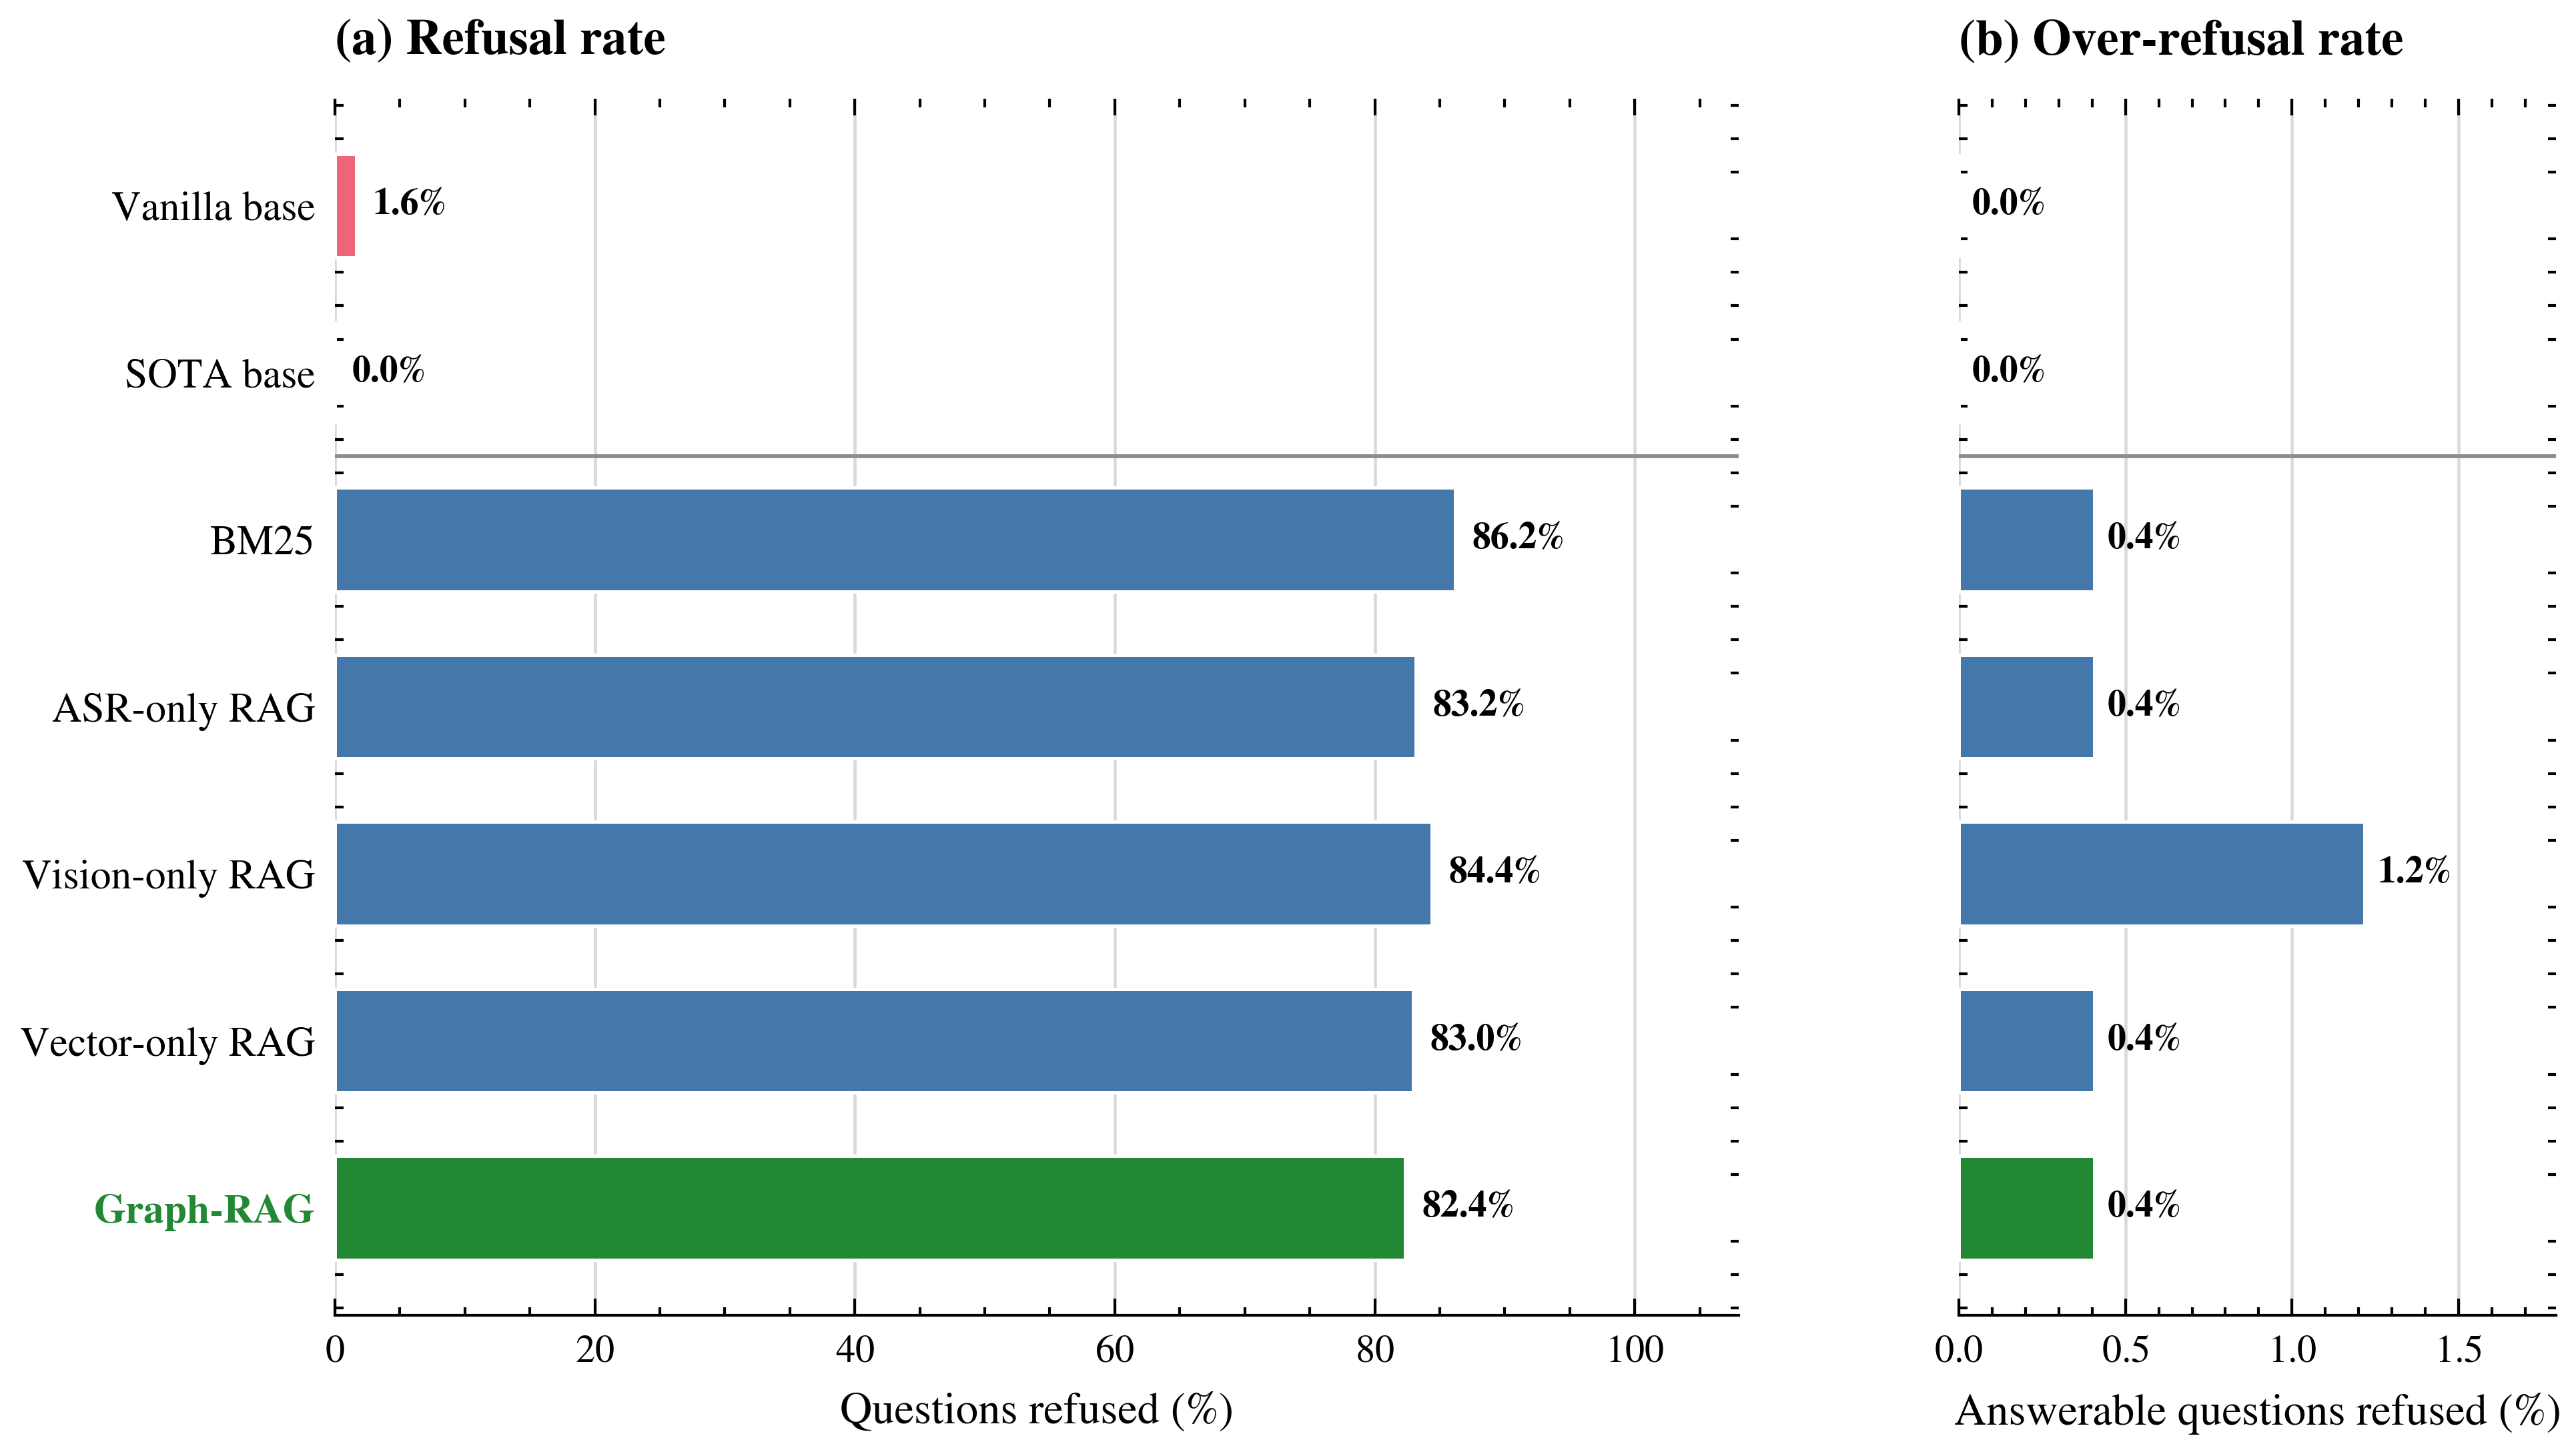

Saved PNG export to /home/gatv-projects/Desktop/project/knowledge_system_evaluation_v2/paper_v2_development/figure_7_refusal_and_overrefusal.png


In [8]:
refusal = 100 * raw_values[:, 4]
overrefusal = 100 * raw_values[:, 5]
system_labels = [label for _, label in systems]
row_colors = [BRIGHT[1] if key in {"vanilla_base", "sota_base"} else BRIGHT[0] for key, _ in systems]
row_colors[-1] = BRIGHT[2]

y = np.arange(len(systems))
fig, (refusal_ax, over_ax) = plt.subplots(1, 2, figsize=(7.16, 4.0), sharey=True, gridspec_kw={"width_ratios": [2.35, 1]}, facecolor="white")
refusal_bars = refusal_ax.barh(y, refusal, color=row_colors, height=0.62, edgecolor="white", linewidth=0.6)
over_bars = over_ax.barh(y, overrefusal, color=row_colors, height=0.62, edgecolor="white", linewidth=0.6)
for bar, value in zip(refusal_bars, refusal):
    refusal_ax.text(value + 1.3, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", va="center", fontsize=6.7, fontweight="semibold")
for bar, value in zip(over_bars, overrefusal):
    over_ax.text(value + 0.04, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", va="center", fontsize=6.7, fontweight="semibold")

refusal_ax.set_yticks(y, system_labels)
refusal_ax.invert_yaxis()
refusal_ax.set_xlim(0, 108)
over_ax.set_xlim(0, max(overrefusal) * 1.35 + 0.15)
refusal_ax.set_title("(a) Refusal rate", loc="left", pad=8)
over_ax.set_title("(b) Over-refusal rate", loc="left", pad=8)
refusal_ax.set_xlabel("Questions refused (%)")
over_ax.set_xlabel("Answerable questions refused (%)")
for ax in (refusal_ax, over_ax):
    ax.set_axisbelow(True)
    ax.grid(axis="x", color="#D9D9D9", linewidth=0.55)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.axhline(1.5, color="#8C8C8C", linewidth=0.7)
refusal_ax.get_yticklabels()[-1].set_color(BRIGHT[2])
refusal_ax.get_yticklabels()[-1].set_fontweight("bold")
fig.subplots_adjust(left=0.21, right=0.985, top=0.90, bottom=0.14, wspace=0.22)
output_path = output_dir / "figure_7_refusal_and_overrefusal.png"
fig.savefig(output_path, dpi=600, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print(f"Saved PNG export to {output_path.resolve()}")

# Figure 8 — Modality Ablation Comparison

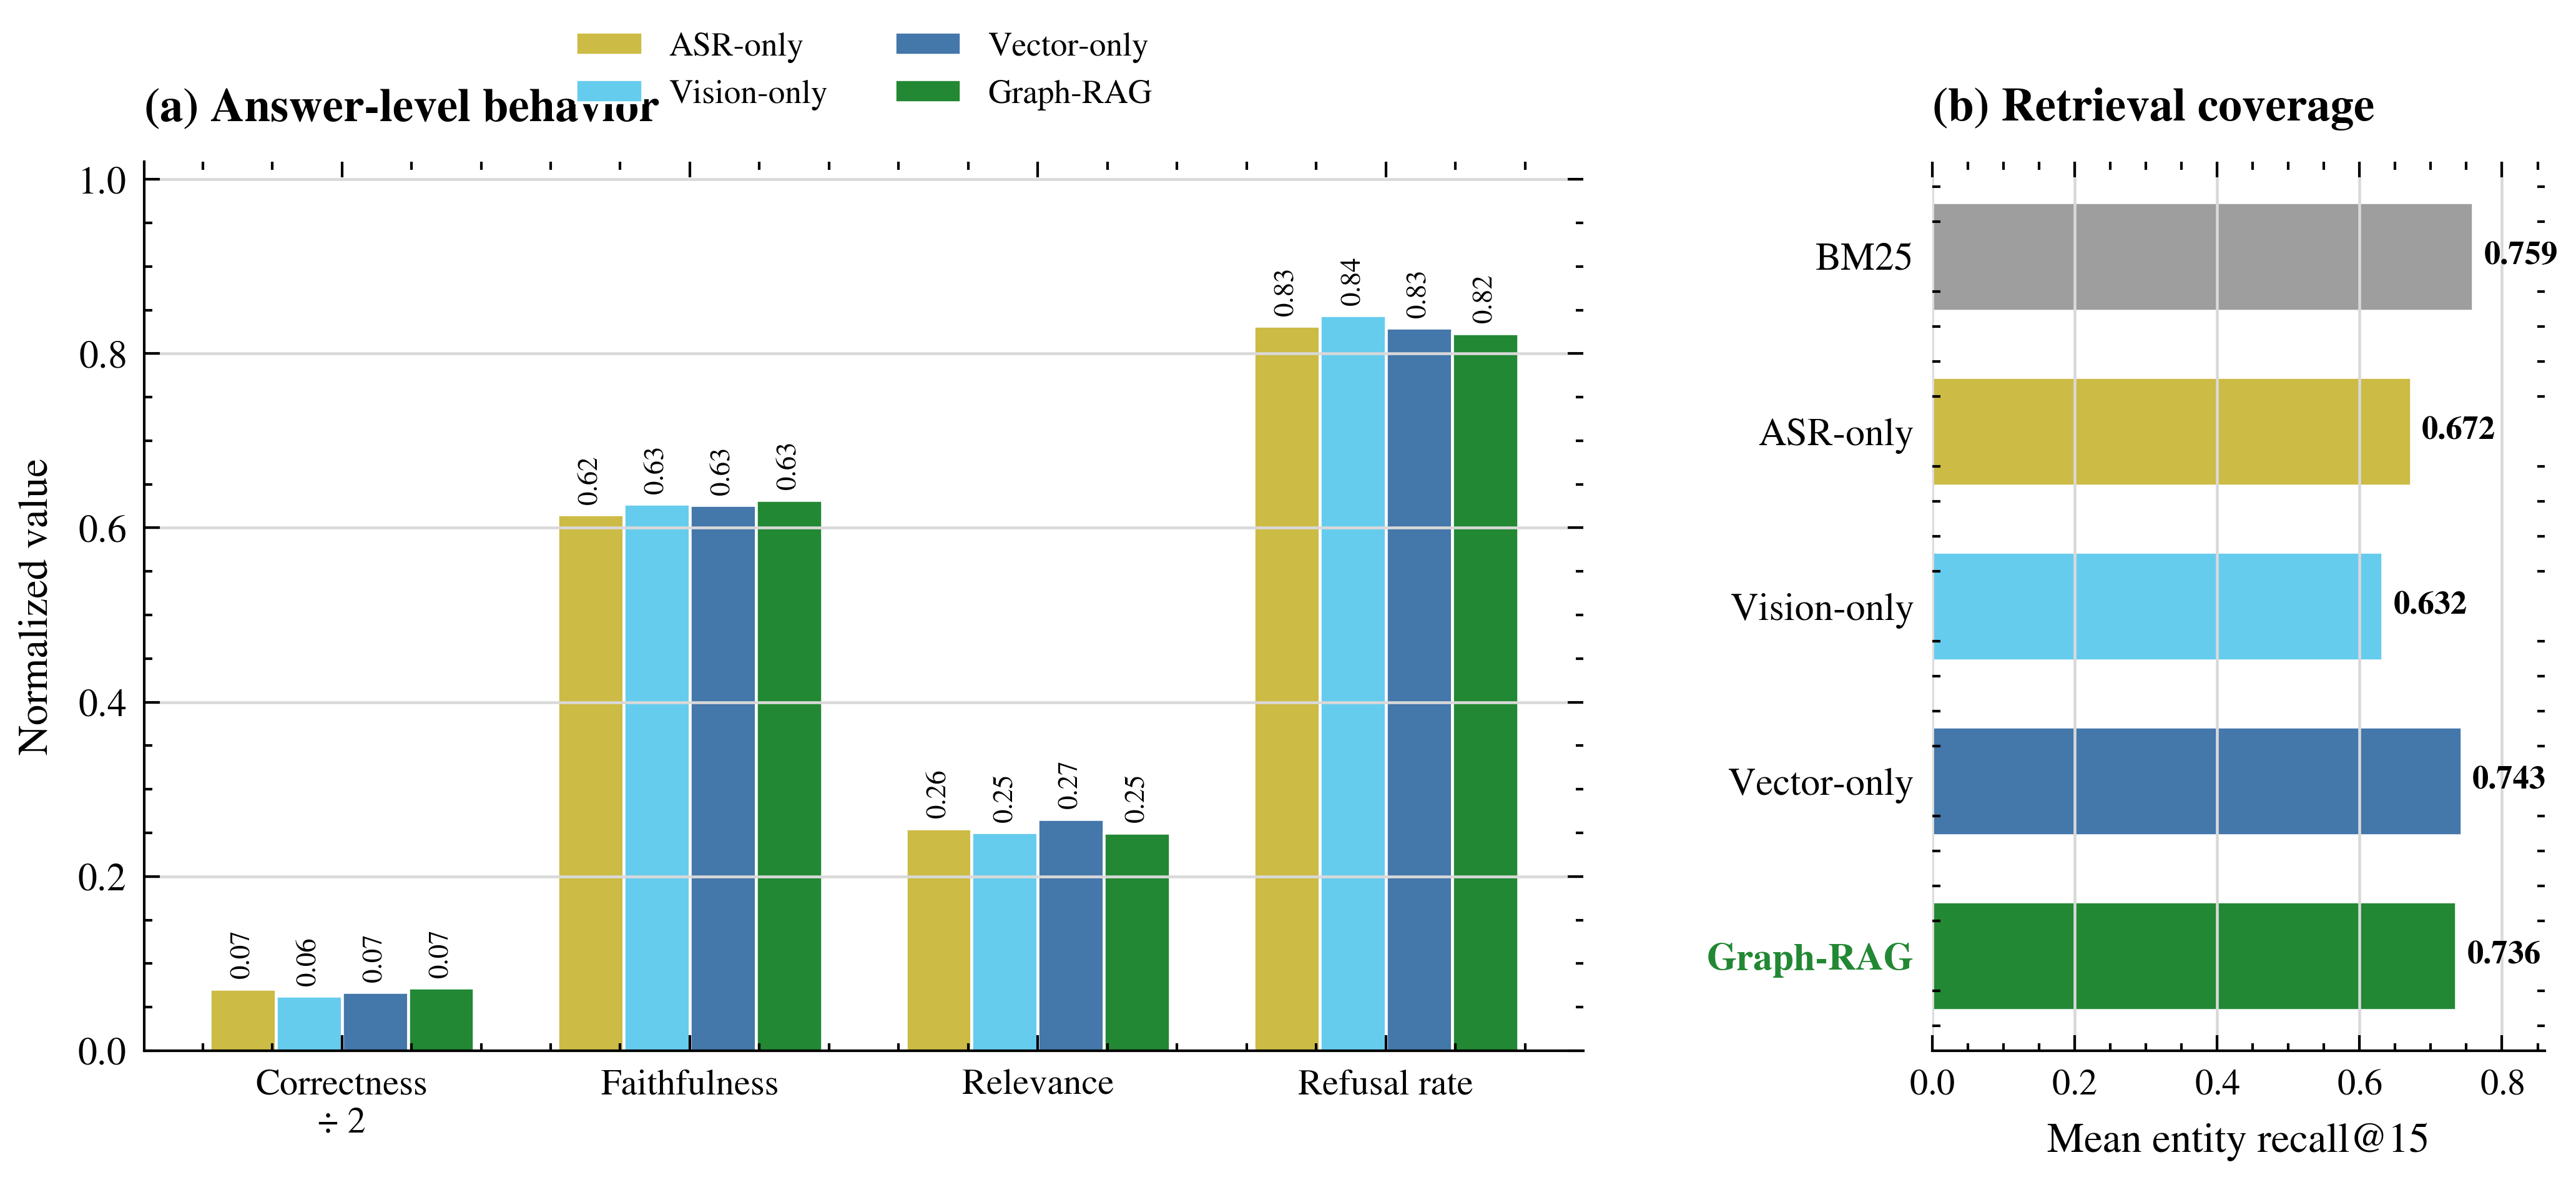

Loaded retrieval metrics from /home/gatv-projects/Desktop/project/knowledge_system_evaluation_v2/other_stuff/retrieval_metrics.json
Saved PNG export to /home/gatv-projects/Desktop/project/knowledge_system_evaluation_v2/paper_v2_development/figure_8_modality_ablation_comparison.png


In [9]:
modality_systems = [
    ("asr_only", "ASR-only", BRIGHT[3]),
    ("vision_only", "Vision-only", BRIGHT[4]),
    ("vector_only", "Vector-only", BRIGHT[0]),
    ("graph_rag", "Graph-RAG", BRIGHT[2]),
]
primary_columns = [1, 2, 3, 4]
primary_labels = ["Correctness\n÷ 2", "Faithfulness", "Relevance", "Refusal rate"]
x = np.arange(len(primary_columns))
width = 0.19

fig, (metric_ax, recall_ax) = plt.subplots(1, 2, figsize=(7.16, 3.65), gridspec_kw={"width_ratios": [2.35, 1]}, facecolor="white")
for system_position, (key, label, color) in enumerate(modality_systems):
    row = system_index[key]
    values = raw_values[row, primary_columns].copy()
    values[0] /= 2.0
    bars = metric_ax.bar(x + (system_position - 1.5) * width, values, width=width, color=color, label=label, edgecolor="white", linewidth=0.55)
    for bar, value in zip(bars, values):
        metric_ax.text(bar.get_x() + bar.get_width() / 2, value + 0.012, f"{value:.2f}", ha="center", va="bottom", fontsize=5.4, rotation=90)

metric_ax.set_title("(a) Answer-level behavior", loc="left", pad=8)
metric_ax.set_xticks(x, primary_labels)
metric_ax.set_ylabel("Normalized value")
metric_ax.set_ylim(0, 1.02)
metric_ax.grid(axis="y", color="#D9D9D9", linewidth=0.55)
metric_ax.spines[["top", "right"]].set_visible(False)
metric_ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=2, frameon=False, fontsize=6.4)

retrieval_path = dataset_path.parents[1] / "other_stuff/retrieval_metrics.json"
with retrieval_path.open(encoding="utf-8") as file:
    retrieval_metrics = json.load(file)
recall_systems = [
    ("bm25", "BM25", "#9E9E9E"),
    ("asr_only", "ASR-only", BRIGHT[3]),
    ("vision_only", "Vision-only", BRIGHT[4]),
    ("vector_only", "Vector-only", BRIGHT[0]),
    ("graph_rag", "Graph-RAG", BRIGHT[2]),
]
recalls = [retrieval_metrics[key]["mean_entity_recall_15"] for key, _, _ in recall_systems]
recall_y = np.arange(len(recall_systems))
bars = recall_ax.barh(recall_y, recalls, color=[color for _, _, color in recall_systems], height=0.62, edgecolor="white", linewidth=0.55)
recall_ax.set_yticks(recall_y, [label for _, label, _ in recall_systems])
recall_ax.invert_yaxis()
recall_ax.set_xlim(0, 0.86)
recall_ax.set_xlabel("Mean entity recall@15")
recall_ax.set_title("(b) Retrieval coverage", loc="left", pad=8)
recall_ax.grid(axis="x", color="#D9D9D9", linewidth=0.55)
recall_ax.spines[["top", "right", "left"]].set_visible(False)
recall_ax.tick_params(axis="y", length=0)
for bar, value in zip(bars, recalls):
    recall_ax.text(value + 0.015, bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center", fontsize=6.3, fontweight="semibold")
recall_ax.get_yticklabels()[-1].set_color(BRIGHT[2])
recall_ax.get_yticklabels()[-1].set_fontweight("bold")
fig.subplots_adjust(left=0.095, right=0.99, top=0.82, bottom=0.17, wspace=0.34)
output_path = output_dir / "figure_8_modality_ablation_comparison.png"
fig.savefig(output_path, dpi=600, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print(f"Loaded retrieval metrics from {retrieval_path}")
print(f"Saved PNG export to {output_path.resolve()}")

# Figure 9 — Graph-RAG Evidence Source Composition

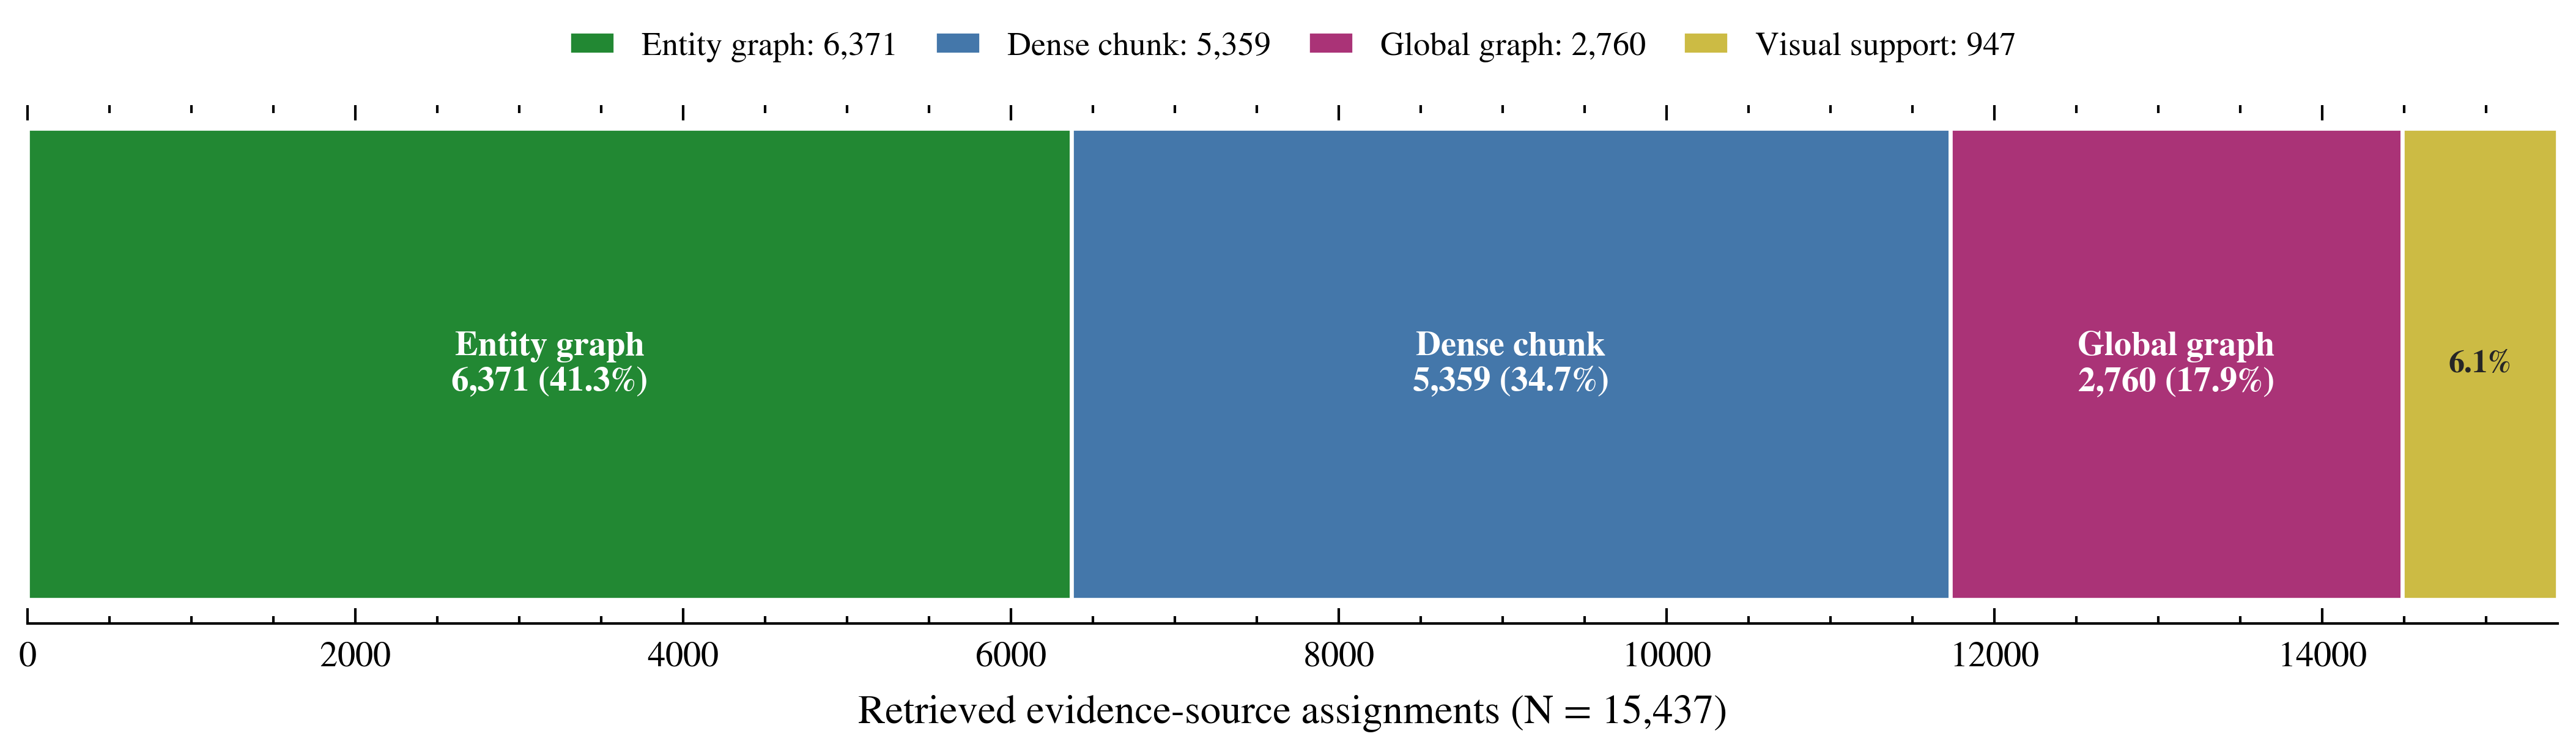

{'Entity graph': 6371, 'Dense chunk': 5359, 'Global graph': 2760, 'Visual support': 947}
Saved PNG export to /home/gatv-projects/Desktop/project/knowledge_system_evaluation_v2/paper_v2_development/figure_9_graph_rag_evidence_sources.png


In [10]:
from collections import Counter

source_counts = Counter()
for record in records:
    for source_path in record["ablations"]["graph_rag"].get("evidence_sources", []):
        source_counts.update(part for part in source_path.split("|") if part)
source_order = ["entity_graph", "dense_chunk", "global_graph", "visual_support"]
source_labels = ["Entity graph", "Dense chunk", "Global graph", "Visual support"]
values = np.array([source_counts[source] for source in source_order])
assert values.tolist() == [6371, 5359, 2760, 947]
total_evidence = int(values.sum())
percentages = 100 * values / total_evidence
colors = [BRIGHT[2], BRIGHT[0], BRIGHT[5], BRIGHT[3]]

fig, ax = plt.subplots(figsize=(7.16, 2.25), facecolor="white")
left = 0
for label, value, percentage, color in zip(source_labels, values, percentages, colors):
    ax.barh([0], [value], left=left, height=0.48, color=color, edgecolor="white", linewidth=0.8, label=f"{label}: {value:,}")
    cell_label = f"{label}\n{value:,} ({percentage:.1f}%)" if percentage >= 12 else f"{percentage:.1f}%"
    ax.text(left + value / 2, 0, cell_label, ha="center", va="center", fontsize=6.8 if percentage >= 12 else 6.2, color="white" if color != BRIGHT[3] else "#262626", fontweight="semibold")
    left += value
ax.set_xlim(0, total_evidence)
ax.set_yticks([])
ax.set_xlabel(f"Retrieved evidence-source assignments (N = {total_evidence:,})")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.20), ncol=4, frameon=False, fontsize=6.5, handlelength=1.4, columnspacing=1.1)
fig.tight_layout()
output_path = output_dir / "figure_9_graph_rag_evidence_sources.png"
fig.savefig(output_path, dpi=600, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print(dict(zip(source_labels, values.tolist())))
print(f"Saved PNG export to {output_path.resolve()}")

# Figure 10 — Current Versus Legacy Performance

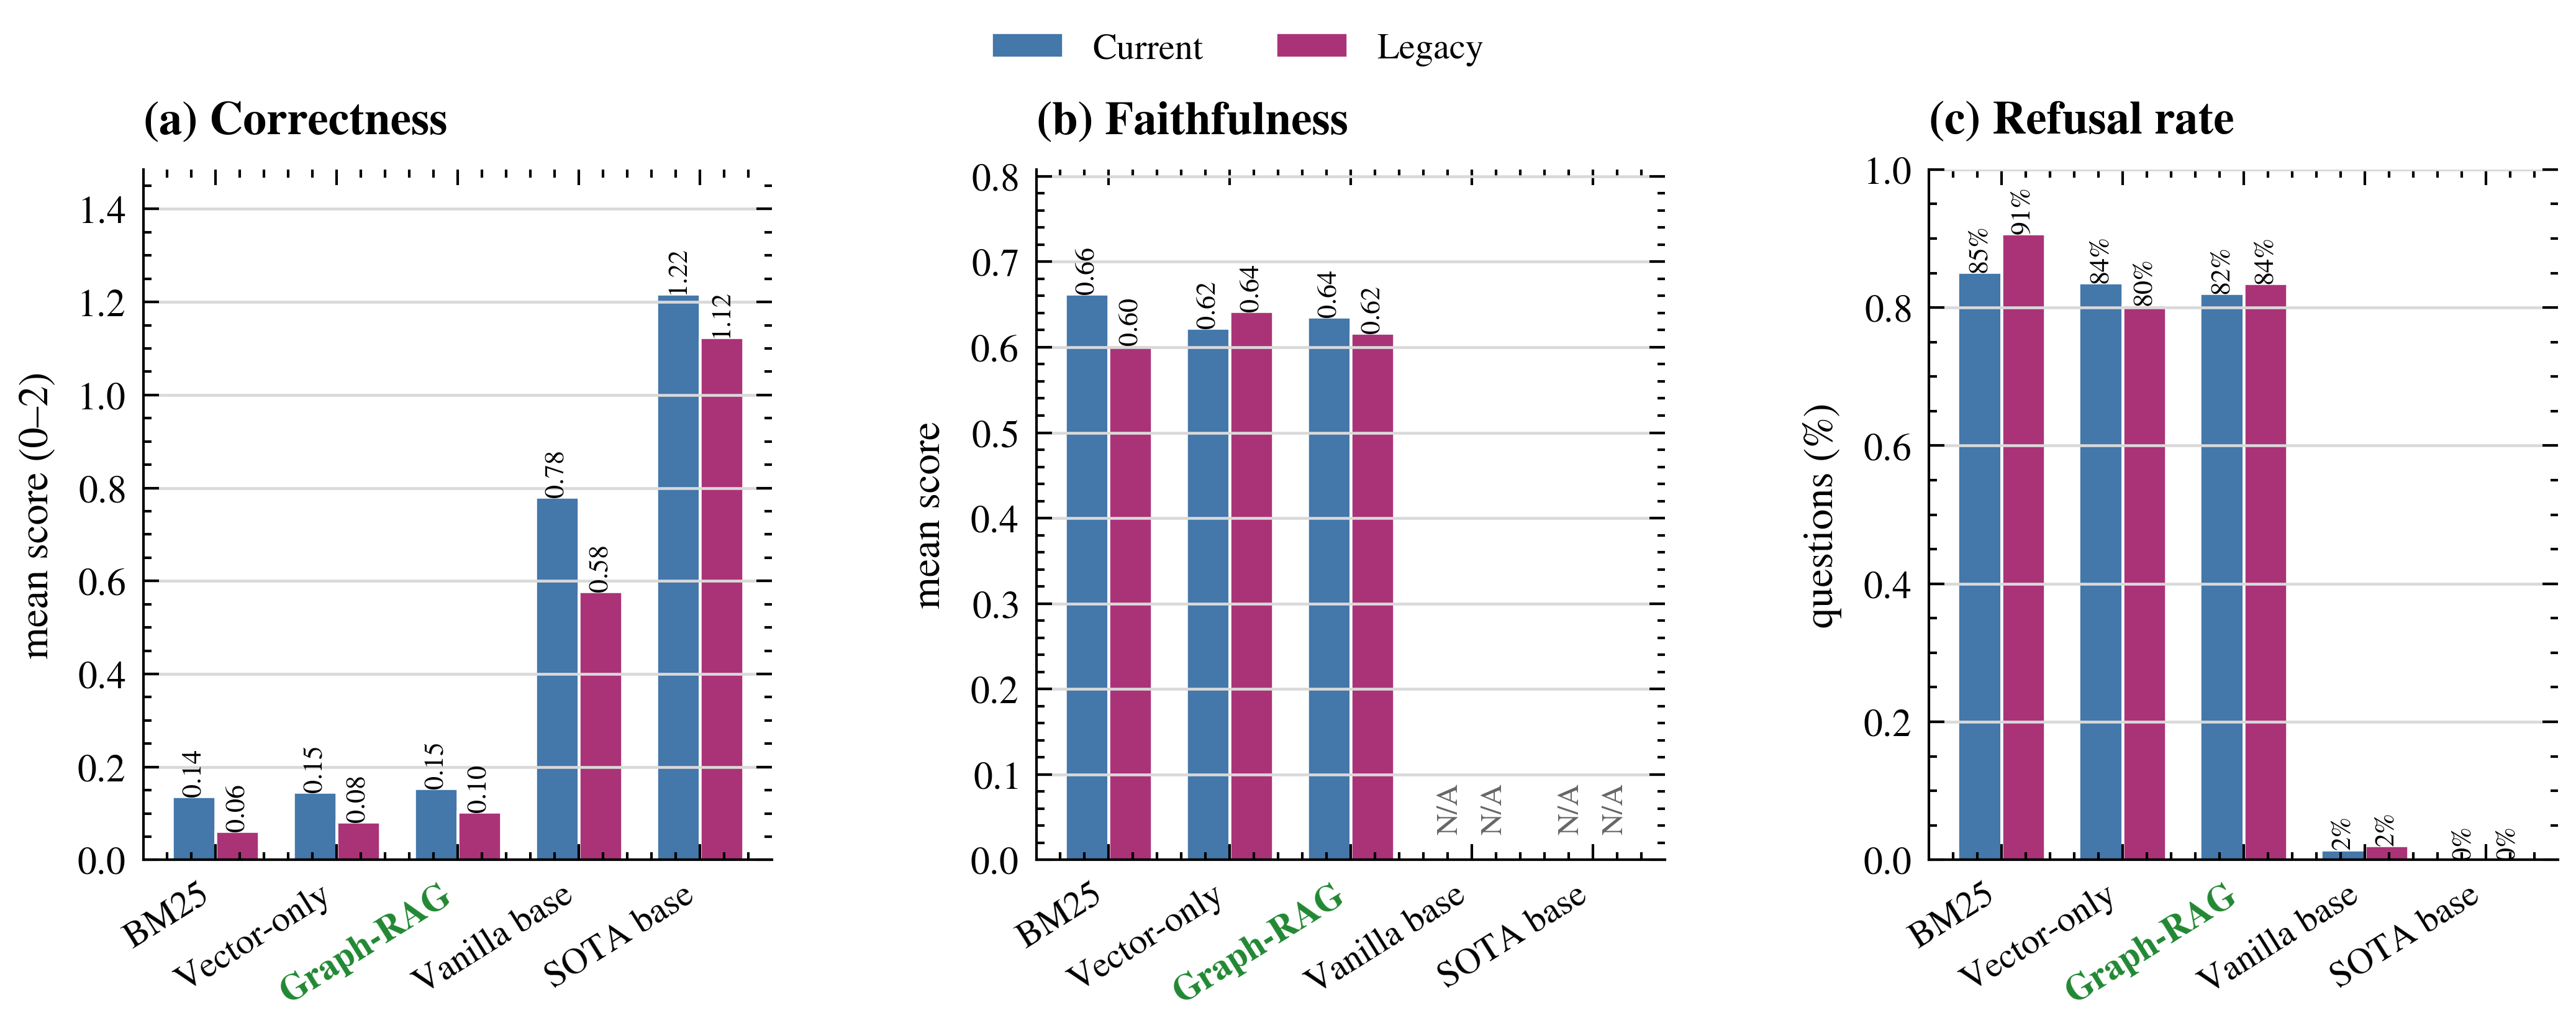

Saved PNG export to /home/gatv-projects/Desktop/project/knowledge_system_evaluation_v2/paper_v2_development/figure_10_current_vs_legacy_performance.png


In [11]:
temporal_systems = [
    ("bm25", "BM25"),
    ("vector_only", "Vector-only"),
    ("graph_rag", "Graph-RAG"),
    ("vanilla_base", "Vanilla base"),
    ("sota_base", "SOTA base"),
]
temporal_groups = [("Current", BRIGHT[0]), ("Legacy", BRIGHT[5])]
temporal_metrics = [
    ("correctness_score", "(a) Correctness", "mean score (0–2)", False),
    ("faithfulness", "(b) Faithfulness", "mean score", False),
    ("is_refusal", "(c) Refusal rate", "questions (%)", True),
]


def temporal_mean(system_key, metric_key, temporal_status):
    values = [
        record["ablations"][system_key][metric_key]
        for record in records
        if record["temporal_status"] == temporal_status
        and record["ablations"][system_key][metric_key] is not None
    ]
    return np.nan if not values else float(np.mean([float(value) for value in values]))


fig, axes = plt.subplots(1, 3, figsize=(7.16, 3.25), facecolor="white")
x = np.arange(len(temporal_systems))
width = 0.36
for ax, (metric_key, title, ylabel, percentage) in zip(axes, temporal_metrics):
    all_values = []
    for offset, (temporal_status, color) in zip((-width / 2, width / 2), temporal_groups):
        values = np.array([temporal_mean(system_key, metric_key, temporal_status) for system_key, _ in temporal_systems])
        all_values.extend(values[np.isfinite(values)])
        bars = ax.bar(x + offset, np.nan_to_num(values), width=width, color=color, label=temporal_status, edgecolor="white", linewidth=0.55)
        for position, (bar, value) in enumerate(zip(bars, values)):
            if np.isnan(value):
                ax.text(bar.get_x() + bar.get_width() / 2, 0.03, "N/A", ha="center", va="bottom", fontsize=5.8, rotation=90, color="#666666")
            else:
                label = f"{100 * value:.0f}%" if percentage else f"{value:.2f}"
                ax.text(bar.get_x() + bar.get_width() / 2, value, label, ha="center", va="bottom", fontsize=5.3, rotation=90)
    ax.set_title(title, loc="left", pad=7)
    ax.set_xticks(x, [label for _, label in temporal_systems], rotation=32, ha="right")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", color="#D9D9D9", linewidth=0.55)
    ax.spines[["top", "right"]].set_visible(False)
    max_value = max(all_values) if all_values else 1
    ax.set_ylim(0, 1.0 if percentage else max_value * 1.22)
    ax.get_xticklabels()[2].set_color(BRIGHT[2])
    ax.get_xticklabels()[2].set_fontweight("bold")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False, fontsize=7)
fig.subplots_adjust(left=0.09, right=0.995, top=0.86, bottom=0.29, wspace=0.42)
output_path = output_dir / "figure_10_current_vs_legacy_performance.png"
fig.savefig(output_path, dpi=600, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print(f"Saved PNG export to {output_path.resolve()}")

# Figure 11 — Answerability Flow Diagram

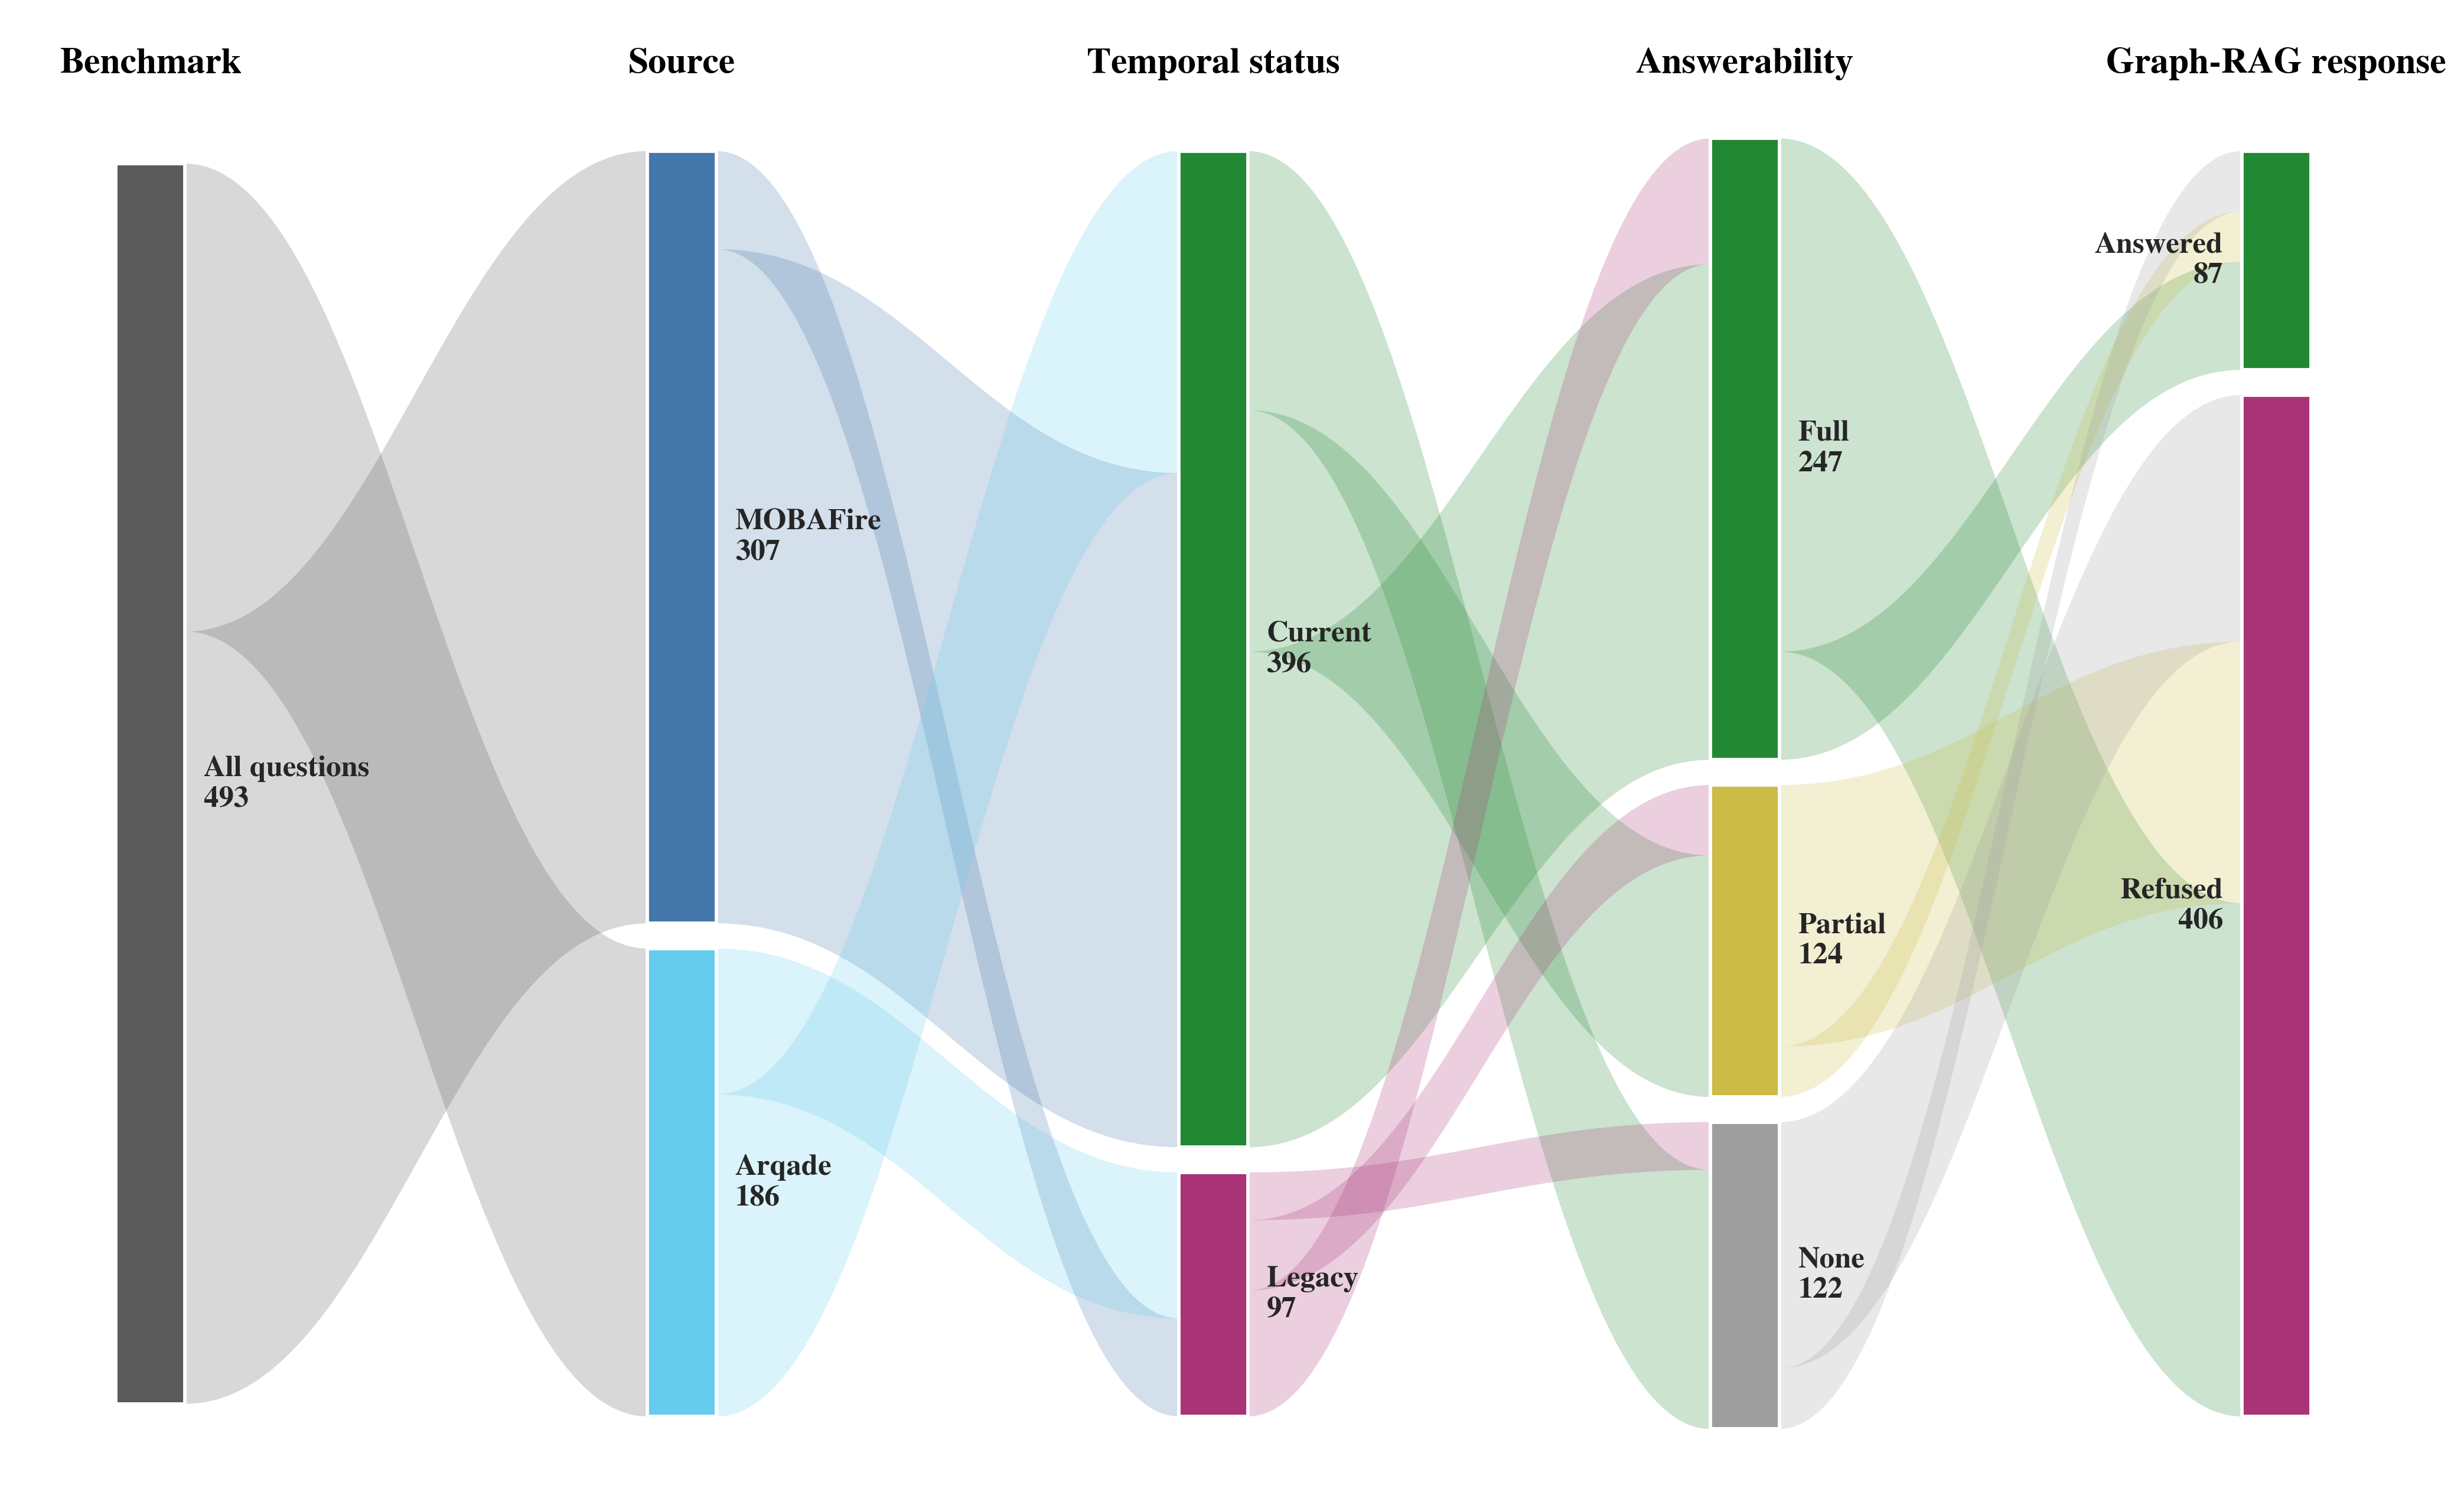

[{'All questions': 493}, {'MOBAFire': 307, 'Arqade': 186}, {'Current': 396, 'Legacy': 97}, {'Full': 247, 'Partial': 124, 'None': 122}, {'Answered': 87, 'Refused': 406}]
Saved PNG export to /home/gatv-projects/Desktop/project/knowledge_system_evaluation_v2/paper_v2_development/figure_11_answerability_flow_diagram.png


In [12]:
from collections import Counter
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch

stage_defs = [
    ("Benchmark", ["All questions"], lambda record: "All questions"),
    ("Source", ["MOBAFire", "Arqade"], lambda record: "MOBAFire" if record["source"] == "mobafire" else "Arqade"),
    ("Temporal status", ["Current", "Legacy"], lambda record: record["temporal_status"]),
    ("Answerability", ["Full", "Partial", "None"], lambda record: record["answerability_status"]),
    ("Graph-RAG response", ["Answered", "Refused"], lambda record: "Refused" if record["ablations"]["graph_rag"]["is_refusal"] else "Answered"),
]
stage_colors = [
    {"All questions": "#5A5A5A"},
    {"MOBAFire": BRIGHT[0], "Arqade": BRIGHT[4]},
    {"Current": BRIGHT[2], "Legacy": BRIGHT[5]},
    {"Full": BRIGHT[2], "Partial": BRIGHT[3], "None": "#9E9E9E"},
    {"Answered": BRIGHT[2], "Refused": BRIGHT[5]},
]

stage_values = []
for _, categories, extractor in stage_defs:
    counts = Counter(extractor(record) for record in records)
    stage_values.append({category: counts[category] for category in categories})
assert stage_values[0]["All questions"] == 493
assert stage_values[-1] == {"Answered": 87, "Refused": 406}

transition_counts = []
for stage_index in range(len(stage_defs) - 1):
    source_extractor = stage_defs[stage_index][2]
    target_extractor = stage_defs[stage_index + 1][2]
    transition_counts.append(Counter((source_extractor(record), target_extractor(record)) for record in records))

gap = 10
max_height = len(records) + gap * (max(len(categories) for _, categories, _ in stage_defs) - 1)
node_positions = []
for (_, categories, _), values in zip(stage_defs, stage_values):
    stage_height = len(records) + gap * (len(categories) - 1)
    cursor = max_height - (max_height - stage_height) / 2
    positions = {}
    for category in categories:
        height = values[category]
        positions[category] = (cursor - height, cursor)
        cursor -= height + gap
    node_positions.append(positions)

fig, ax = plt.subplots(figsize=(7.16, 4.35), facecolor="white")
node_width = 0.13
x_positions = np.arange(len(stage_defs), dtype=float)

for stage_index, flows in enumerate(transition_counts):
    source_categories = stage_defs[stage_index][1]
    target_categories = stage_defs[stage_index + 1][1]
    source_cursor = {category: node_positions[stage_index][category][0] for category in source_categories}
    target_cursor = {category: node_positions[stage_index + 1][category][0] for category in target_categories}
    x0 = x_positions[stage_index] + node_width / 2
    x1 = x_positions[stage_index + 1] - node_width / 2
    control_1 = x0 + (x1 - x0) * 0.42
    control_2 = x0 + (x1 - x0) * 0.58
    for source_category in source_categories:
        for target_category in target_categories:
            value = flows[(source_category, target_category)]
            if value == 0:
                continue
            sy0, sy1 = source_cursor[source_category], source_cursor[source_category] + value
            ty0, ty1 = target_cursor[target_category], target_cursor[target_category] + value
            source_cursor[source_category] = sy1
            target_cursor[target_category] = ty1
            vertices = [
                (x0, sy0),
                (control_1, sy0), (control_2, ty0), (x1, ty0),
                (x1, ty1),
                (control_2, ty1), (control_1, sy1), (x0, sy1),
                (x0, sy0),
            ]
            codes = [
                MplPath.MOVETO,
                MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
                MplPath.LINETO,
                MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
                MplPath.CLOSEPOLY,
            ]
            ax.add_patch(PathPatch(MplPath(vertices, codes), facecolor=stage_colors[stage_index][source_category], edgecolor="none", alpha=0.23, zorder=1))

for stage_index, ((stage_title, categories, _), values, positions) in enumerate(zip(stage_defs, stage_values, node_positions)):
    x = x_positions[stage_index]
    ax.text(x, max_height + 23, stage_title, ha="center", va="bottom", fontsize=7.4, fontweight="semibold")
    for category in categories:
        y0, y1 = positions[category]
        color = stage_colors[stage_index][category]
        ax.add_patch(Rectangle((x - node_width / 2, y0), node_width, y1 - y0, facecolor=color, edgecolor="white", linewidth=0.7, zorder=3))
        text_x = x + (0.10 if stage_index < len(stage_defs) - 1 else -0.10)
        alignment = "left" if stage_index < len(stage_defs) - 1 else "right"
        ax.text(text_x, (y0 + y1) / 2, f"{category}\n{values[category]}", ha=alignment, va="center", fontsize=6.1, fontweight="semibold", color="#262626", zorder=4)

ax.set_xlim(-0.25, len(stage_defs) - 0.75)
ax.set_ylim(-18, max_height + 48)
ax.axis("off")
fig.tight_layout()
output_path = output_dir / "figure_11_answerability_flow_diagram.png"
fig.savefig(output_path, dpi=600, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print(stage_values)
print(f"Saved PNG export to {output_path.resolve()}")

# Figure 12 — Correctness Progression on Corpus-Covered Subset


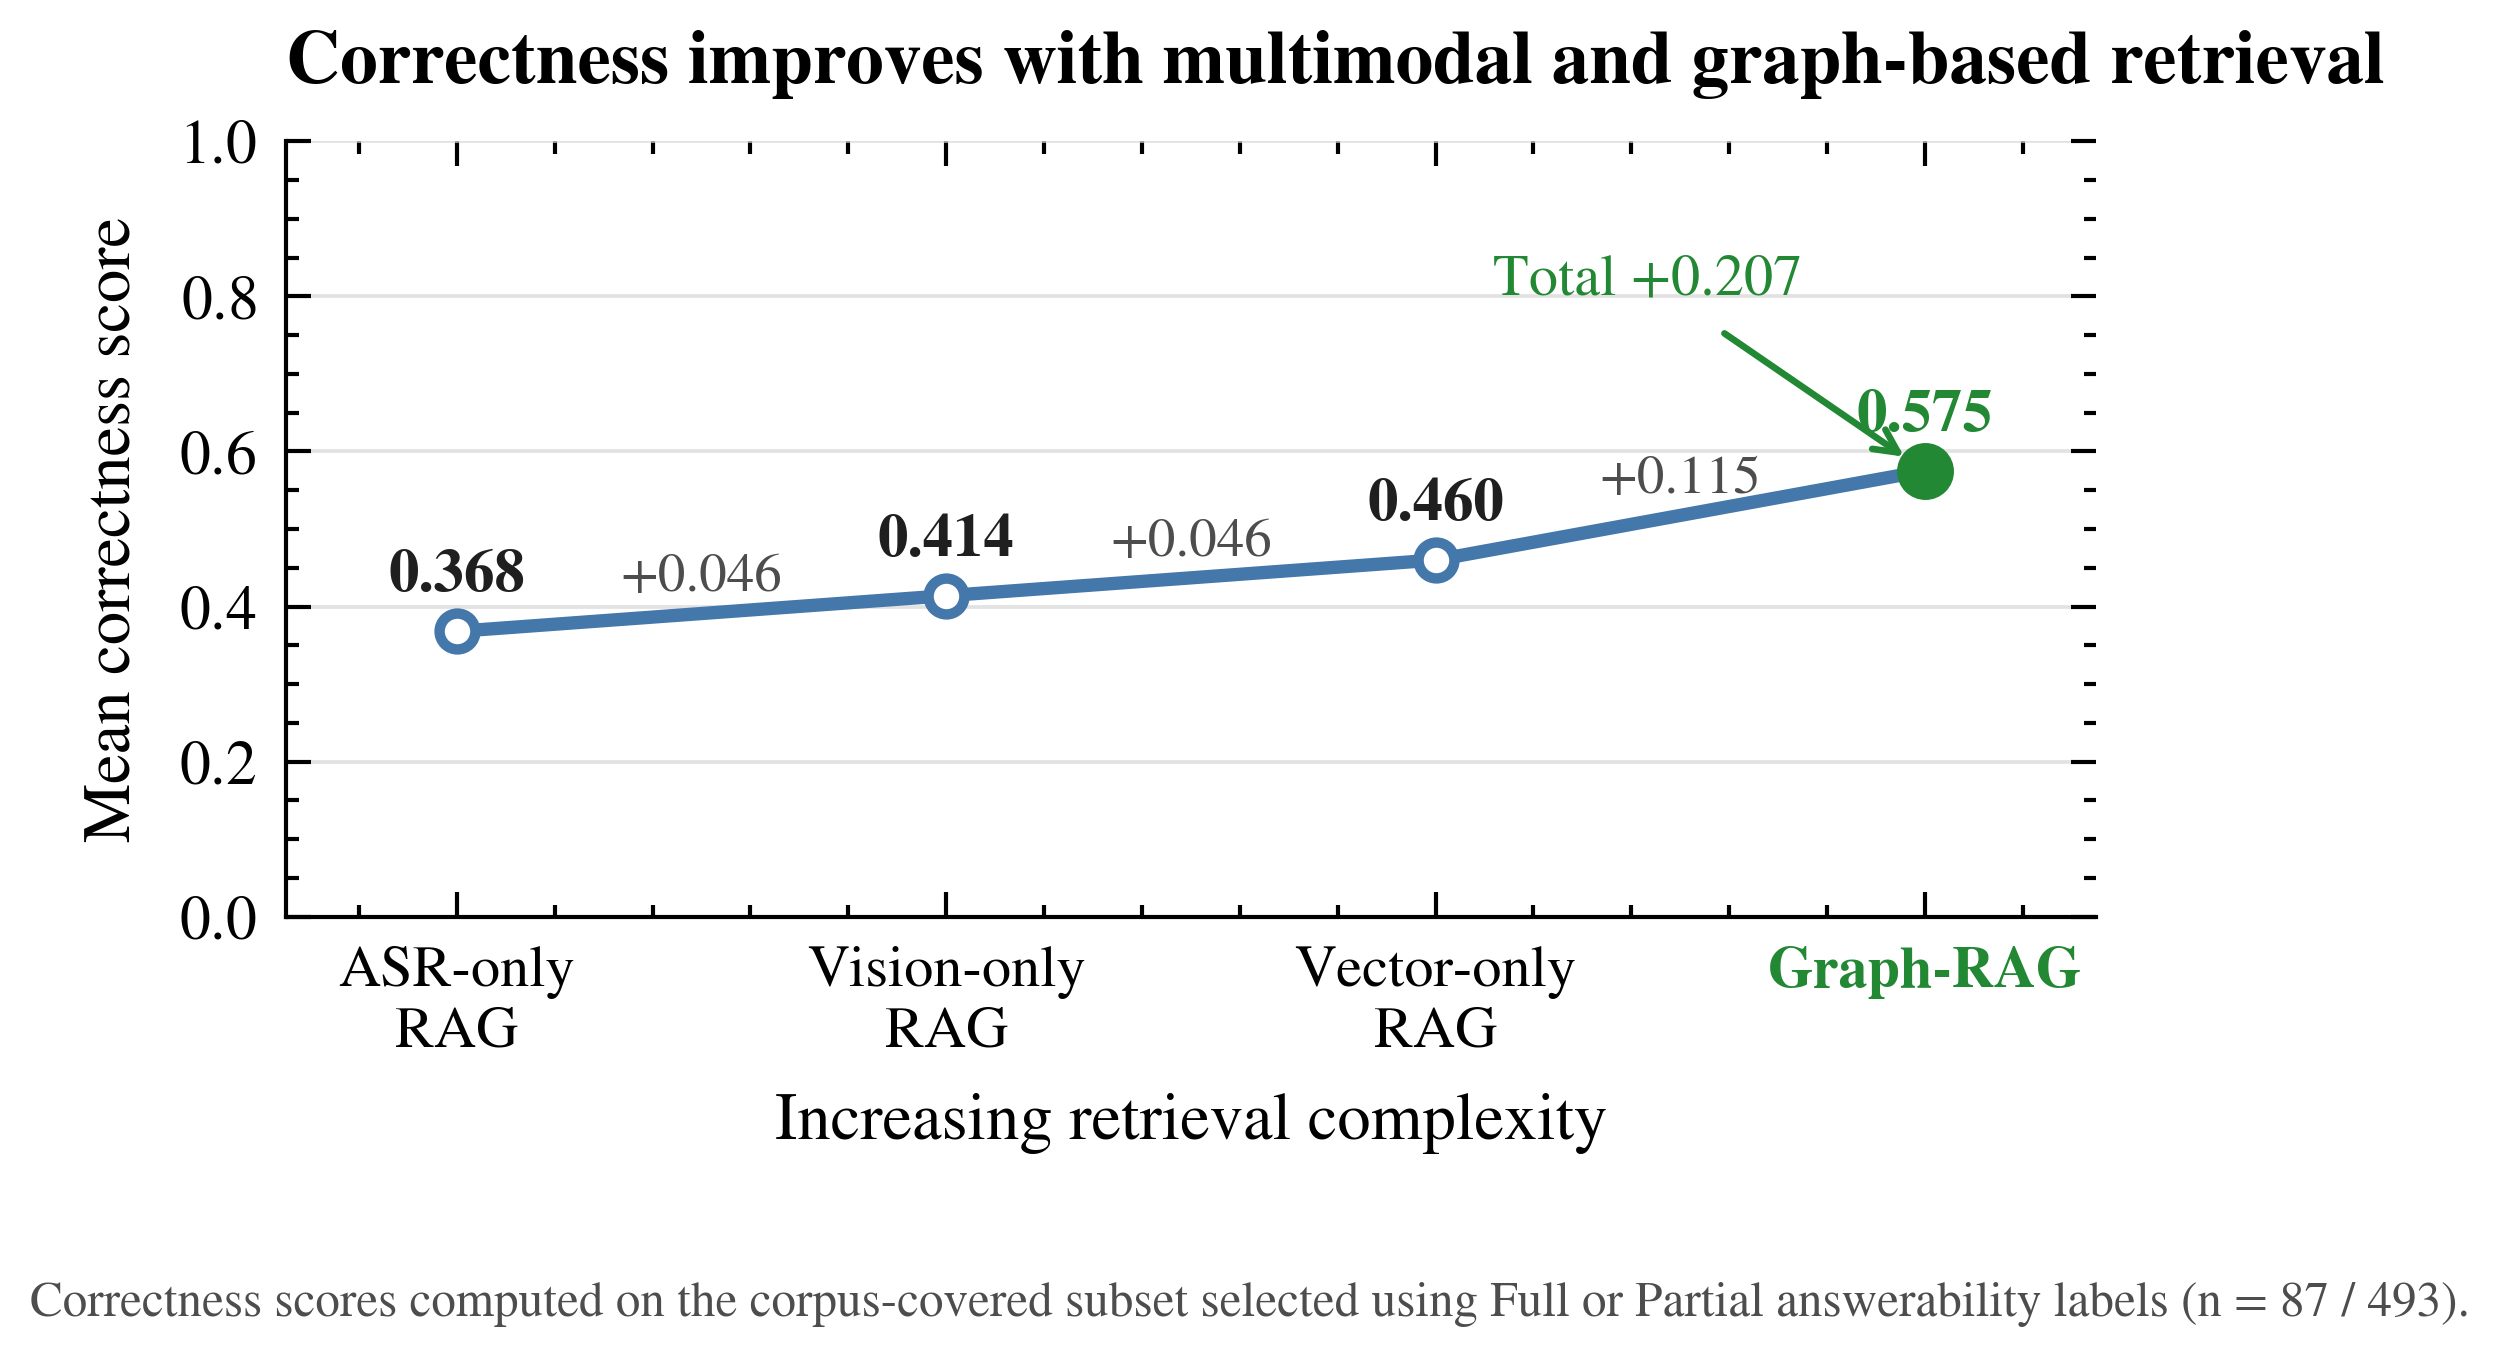

Saved PNG export to /home/gatv-projects/Desktop/project/knowledge_system_evaluation_v2/paper_v2_development/figure_12_subset_correctness_complexity_progression.png
Saved PDF export to /home/gatv-projects/Desktop/project/knowledge_system_evaluation_v2/paper_v2_development/figure_12_subset_correctness_complexity_progression.pdf


In [5]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

# Figure 12 — Correctness progression across increasingly rich retrieval configurations.
# Values are the correctness scores shown in the corpus-covered subset heatmap.
plt.style.use(["science", "ieee", "no-latex", "bright"])
mpl.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.titleweight": "semibold",
    "xtick.labelsize": 7,
    "ytick.labelsize": 7.4,
    "savefig.dpi": 600,
})
BRIGHT = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

complexity_labels = [
    "ASR-only\nRAG",
    "Vision-only\nRAG",
    "Vector-only\nRAG",
    "Graph-RAG",
]
correctness_scores = np.array([0.368, 0.414, 0.460, 0.575])
x = np.arange(len(complexity_labels))

fig, ax = plt.subplots(figsize=(3.55, 2.35), facecolor="white")

line_color = BRIGHT[0]
graph_color = BRIGHT[2]

ax.plot(
    x,
    correctness_scores,
    color=line_color,
    linewidth=1.6,
    marker="o",
    markersize=4.3,
    markerfacecolor="white",
    markeredgecolor=line_color,
    markeredgewidth=1.25,
    zorder=3,
)
ax.scatter(
    x[-1],
    correctness_scores[-1],
    s=34,
    color=graph_color,
    edgecolor=graph_color,
    linewidth=1.0,
    zorder=4,
)

for index, score in enumerate(correctness_scores):
    label_color = graph_color if index == len(correctness_scores) - 1 else "#1F1F1F"
    ax.text(
        x[index],
        score + 0.035,
        f"{score:.3f}",
        ha="center",
        va="bottom",
        fontsize=7.3,
        fontweight="semibold",
        color=label_color,
    )

step_deltas = np.diff(correctness_scores)
for index, delta in enumerate(step_deltas):
    midpoint_x = index + 0.5
    midpoint_y = (correctness_scores[index] + correctness_scores[index + 1]) / 2 + 0.045
    ax.text(
        midpoint_x,
        midpoint_y,
        f"+{delta:.3f}",
        ha="center",
        va="center",
        fontsize=6.6,
        color="#4D4D4D",
    )

ax.annotate(
    f"Total +{correctness_scores[-1] - correctness_scores[0]:.3f}",
    xy=(x[-1], correctness_scores[-1]),
    xytext=(x[-1] - 0.25, 0.82),
    ha="right",
    va="center",
    fontsize=7.0,
    color=graph_color,
    arrowprops={
        "arrowstyle": "->",
        "color": graph_color,
        "linewidth": 0.8,
        "shrinkA": 2,
        "shrinkB": 3,
    },
)

ax.set_title("Correctness improves with multimodal and graph-based retrieval", loc="left", pad=7)
ax.set_ylabel("Mean correctness score")
ax.set_xlabel("Increasing retrieval complexity")
ax.set_xticks(x, complexity_labels)
ax.set_ylim(0.0, 1.0)
ax.set_yticks(np.arange(0.0, 1.01, 0.2))
ax.set_xlim(-0.35, len(complexity_labels) - 0.65)
ax.grid(axis="y", color="#D9D9D9", linewidth=0.45, alpha=0.75)
ax.grid(axis="x", visible=False)

for tick_label in ax.get_xticklabels():
    if tick_label.get_text() == "Graph-RAG":
        tick_label.set_color(graph_color)
        tick_label.set_fontweight("bold")

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

fig.text(
    0.02,
    0.015,
    "Correctness scores computed on the corpus-covered subset selected using Full or Partial answerability labels (n = 87 / 493).",
    ha="left",
    va="center",
    fontsize=5.9,
    color="#4D4D4D",
)

fig.subplots_adjust(left=0.14, right=0.99, top=0.84, bottom=0.29)

output_dir = Path.cwd()
if output_dir.name != "paper_v2_development":
    output_dir = Path("knowledge_system_evaluation_v2/paper_v2_development")
output_dir.mkdir(parents=True, exist_ok=True)
output_path_png = output_dir / "figure_12_subset_correctness_complexity_progression.png"
output_path_pdf = output_dir / "figure_12_subset_correctness_complexity_progression.pdf"
fig.savefig(output_path_png, dpi=600, bbox_inches="tight", facecolor="white", transparent=False)
fig.savefig(output_path_pdf, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print(f"Saved PNG export to {output_path_png.resolve()}")
print(f"Saved PDF export to {output_path_pdf.resolve()}")


# Figure 13 — Graph-RAG Corpus-Size Scaling


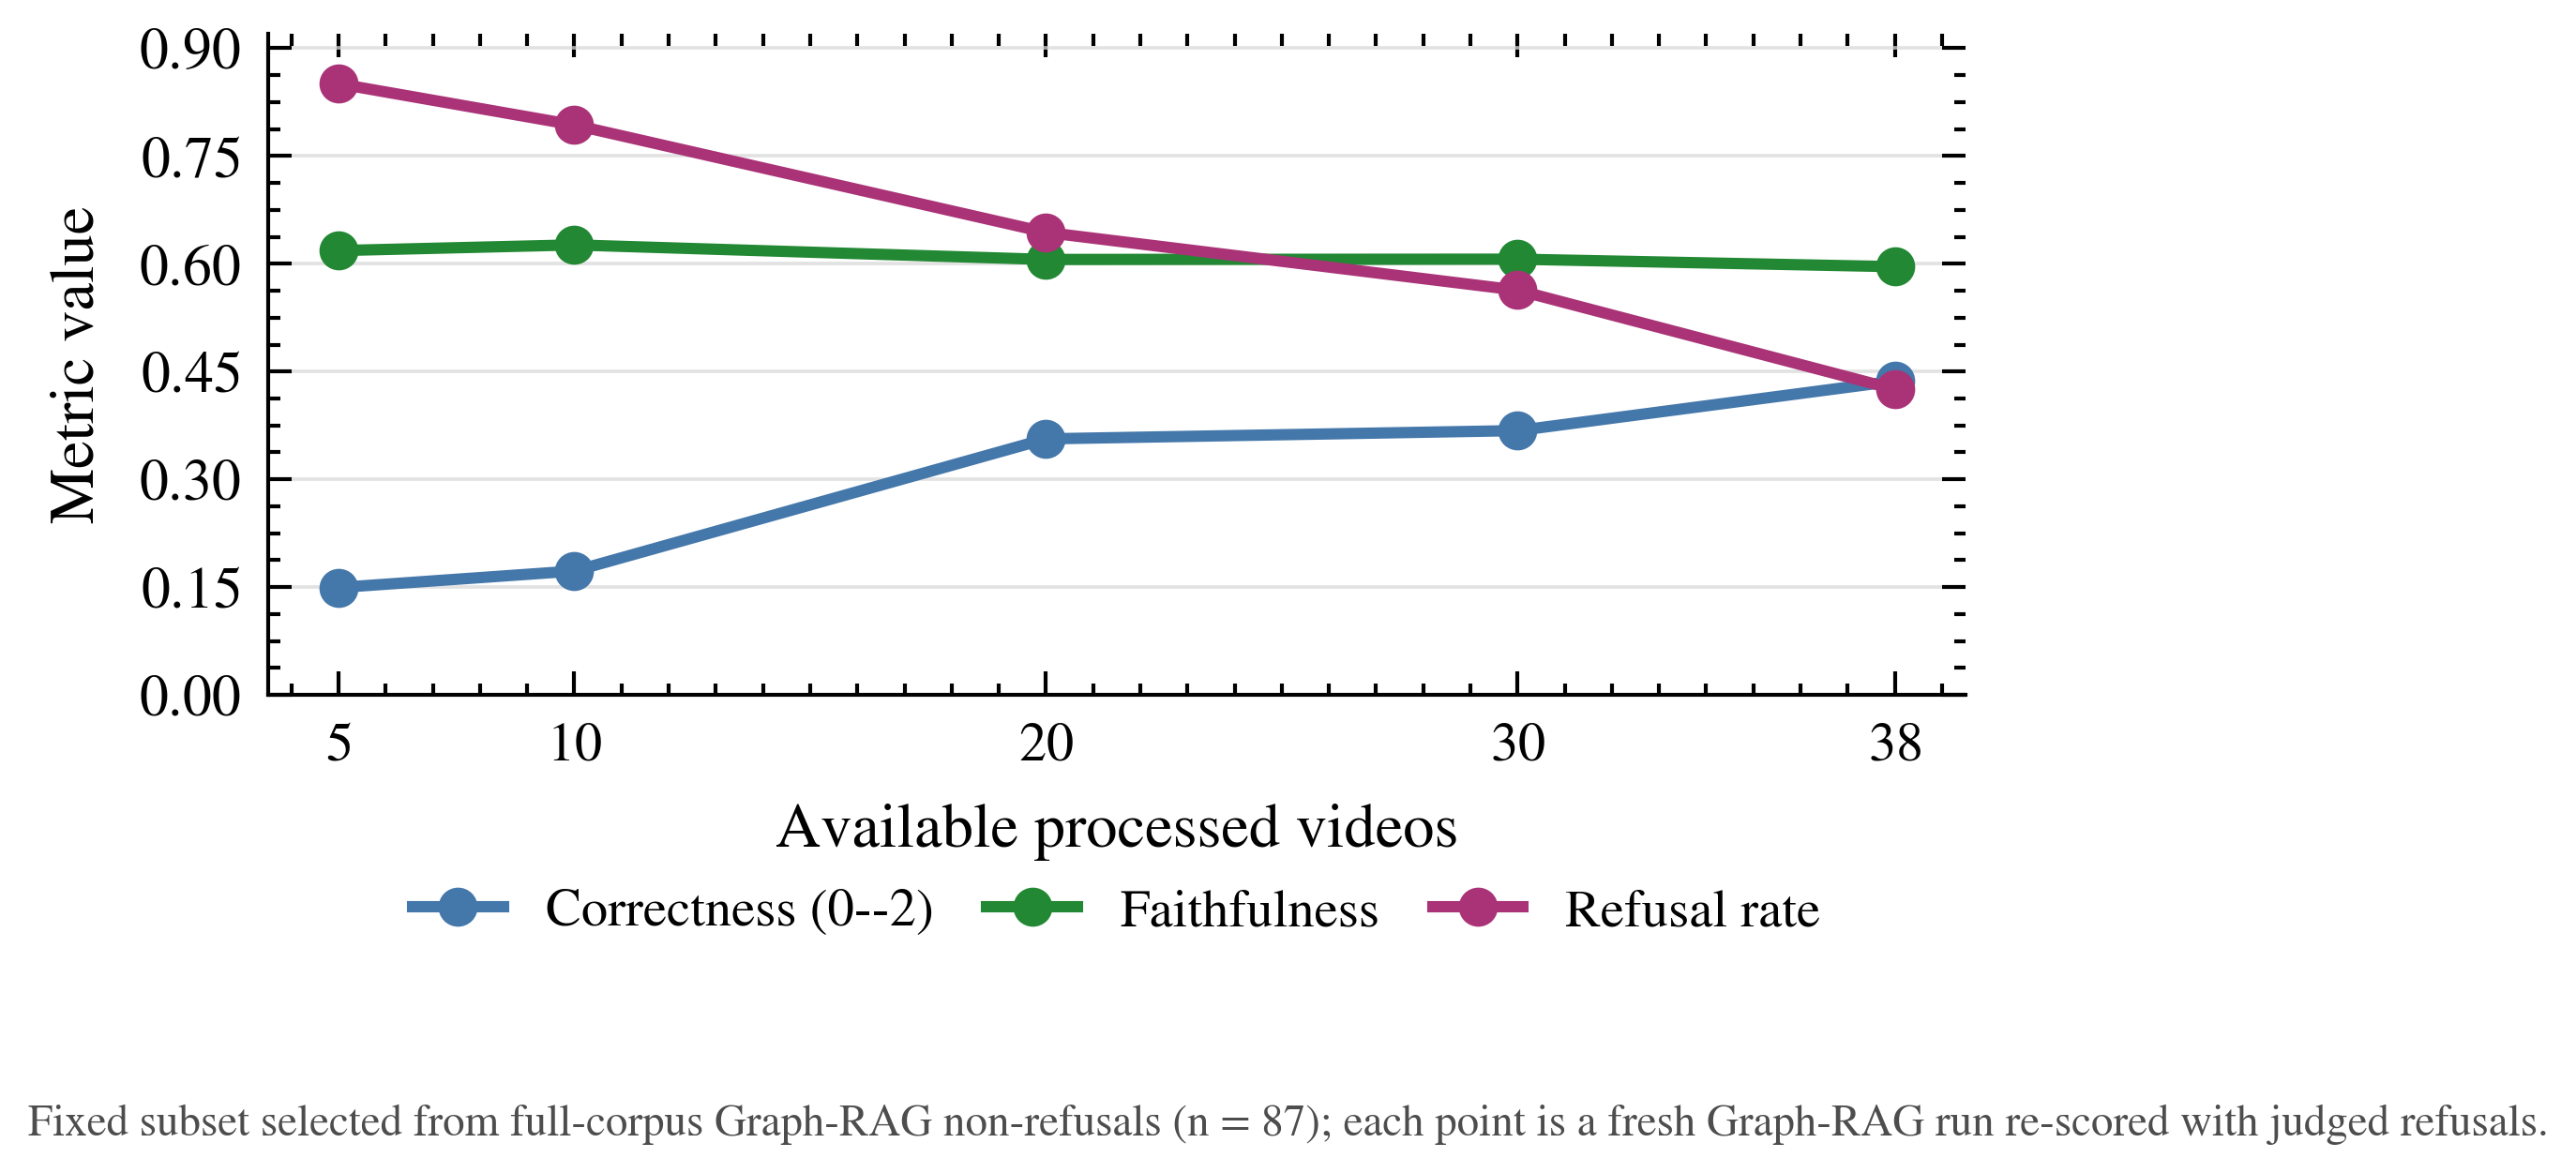

Saved PNG export to /home/gatv-projects/Desktop/project/knowledge_system_evaluation_v2/paper_v2_development/figure_13_corpus_size_scaling.png
Saved PDF export to /home/gatv-projects/Desktop/project/knowledge_system_evaluation_v2/paper_v2_development/figure_13_corpus_size_scaling.pdf


In [2]:
from pathlib import Path
import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

# Figure 13 — Graph-RAG corpus-size scaling.
plt.style.use(["science", "ieee", "no-latex", "bright"])
mpl.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.titleweight": "semibold",
    "xtick.labelsize": 7,
    "ytick.labelsize": 7.4,
    "legend.fontsize": 6.8,
    "savefig.dpi": 600,
})
BRIGHT = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

summary_path = Path("knowledge_system_evaluation_v2/phase_8/graph_rag_corpus_scaling_summary.csv")
if not summary_path.exists():
    summary_path = Path("../phase_8/graph_rag_corpus_scaling_summary.csv")

rows = []
with summary_path.open(encoding="utf-8") as file:
    reader = csv.DictReader(file)
    for row in reader:
        rows.append(row)

num_videos = np.array([int(row["num_videos"]) for row in rows], dtype=float)
correctness = np.array([float(row["mean_correctness"]) for row in rows], dtype=float)
faithfulness = np.array([float(row["mean_faithfulness"]) for row in rows], dtype=float)
refusal = np.array([float(row["refusal_rate"]) for row in rows], dtype=float)

fig, ax = plt.subplots(figsize=(3.55, 2.35), facecolor="white")

ax.plot(
    num_videos,
    correctness,
    color=BRIGHT[0],
    marker="o",
    markersize=4.0,
    linewidth=1.45,
    label="Correctness (0--2)",
)
ax.plot(
    num_videos,
    faithfulness,
    color=BRIGHT[2],
    marker="o",
    markersize=4.0,
    linewidth=1.45,
    label="Faithfulness",
)
ax.plot(
    num_videos,
    refusal,
    color=BRIGHT[5],
    marker="o",
    markersize=4.0,
    linewidth=1.45,
    label="Refusal rate",
)

ax.set_xlabel("Available processed videos")
ax.set_ylabel("Metric value")
ax.set_xticks(num_videos.astype(int))
ax.set_xlim(num_videos.min() - 1.5, num_videos.max() + 1.5)
ax.set_ylim(0.0, 0.92)
ax.set_yticks(np.arange(0.0, 0.91, 0.15))
ax.grid(axis="y", color="#D9D9D9", linewidth=0.45, alpha=0.75)
ax.grid(axis="x", visible=False)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

legend = ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    frameon=False,
    handlelength=1.7,
    columnspacing=1.0,
)

fig.text(
    0.02,
    0.015,
    "Fixed subset selected from full-corpus Graph-RAG non-refusals (n = 87); each point is a fresh Graph-RAG run re-scored with judged refusals.",
    ha="left",
    va="center",
    fontsize=5.65,
    color="#4D4D4D",
)

fig.subplots_adjust(left=0.14, right=0.99, top=0.84, bottom=0.34)

output_dir = Path.cwd()
if output_dir.name != "paper_v2_development":
    output_dir = Path("knowledge_system_evaluation_v2/paper_v2_development")
output_dir.mkdir(parents=True, exist_ok=True)
output_path_png = output_dir / "figure_13_corpus_size_scaling.png"
output_path_pdf = output_dir / "figure_13_corpus_size_scaling.pdf"
fig.savefig(output_path_png, dpi=600, bbox_inches="tight", facecolor="white", transparent=False)
fig.savefig(output_path_pdf, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print(f"Saved PNG export to {output_path_png.resolve()}")
print(f"Saved PDF export to {output_path_pdf.resolve()}")


# Figure 14 — Corpus-Size Scaling with Original Full-Corpus Endpoint


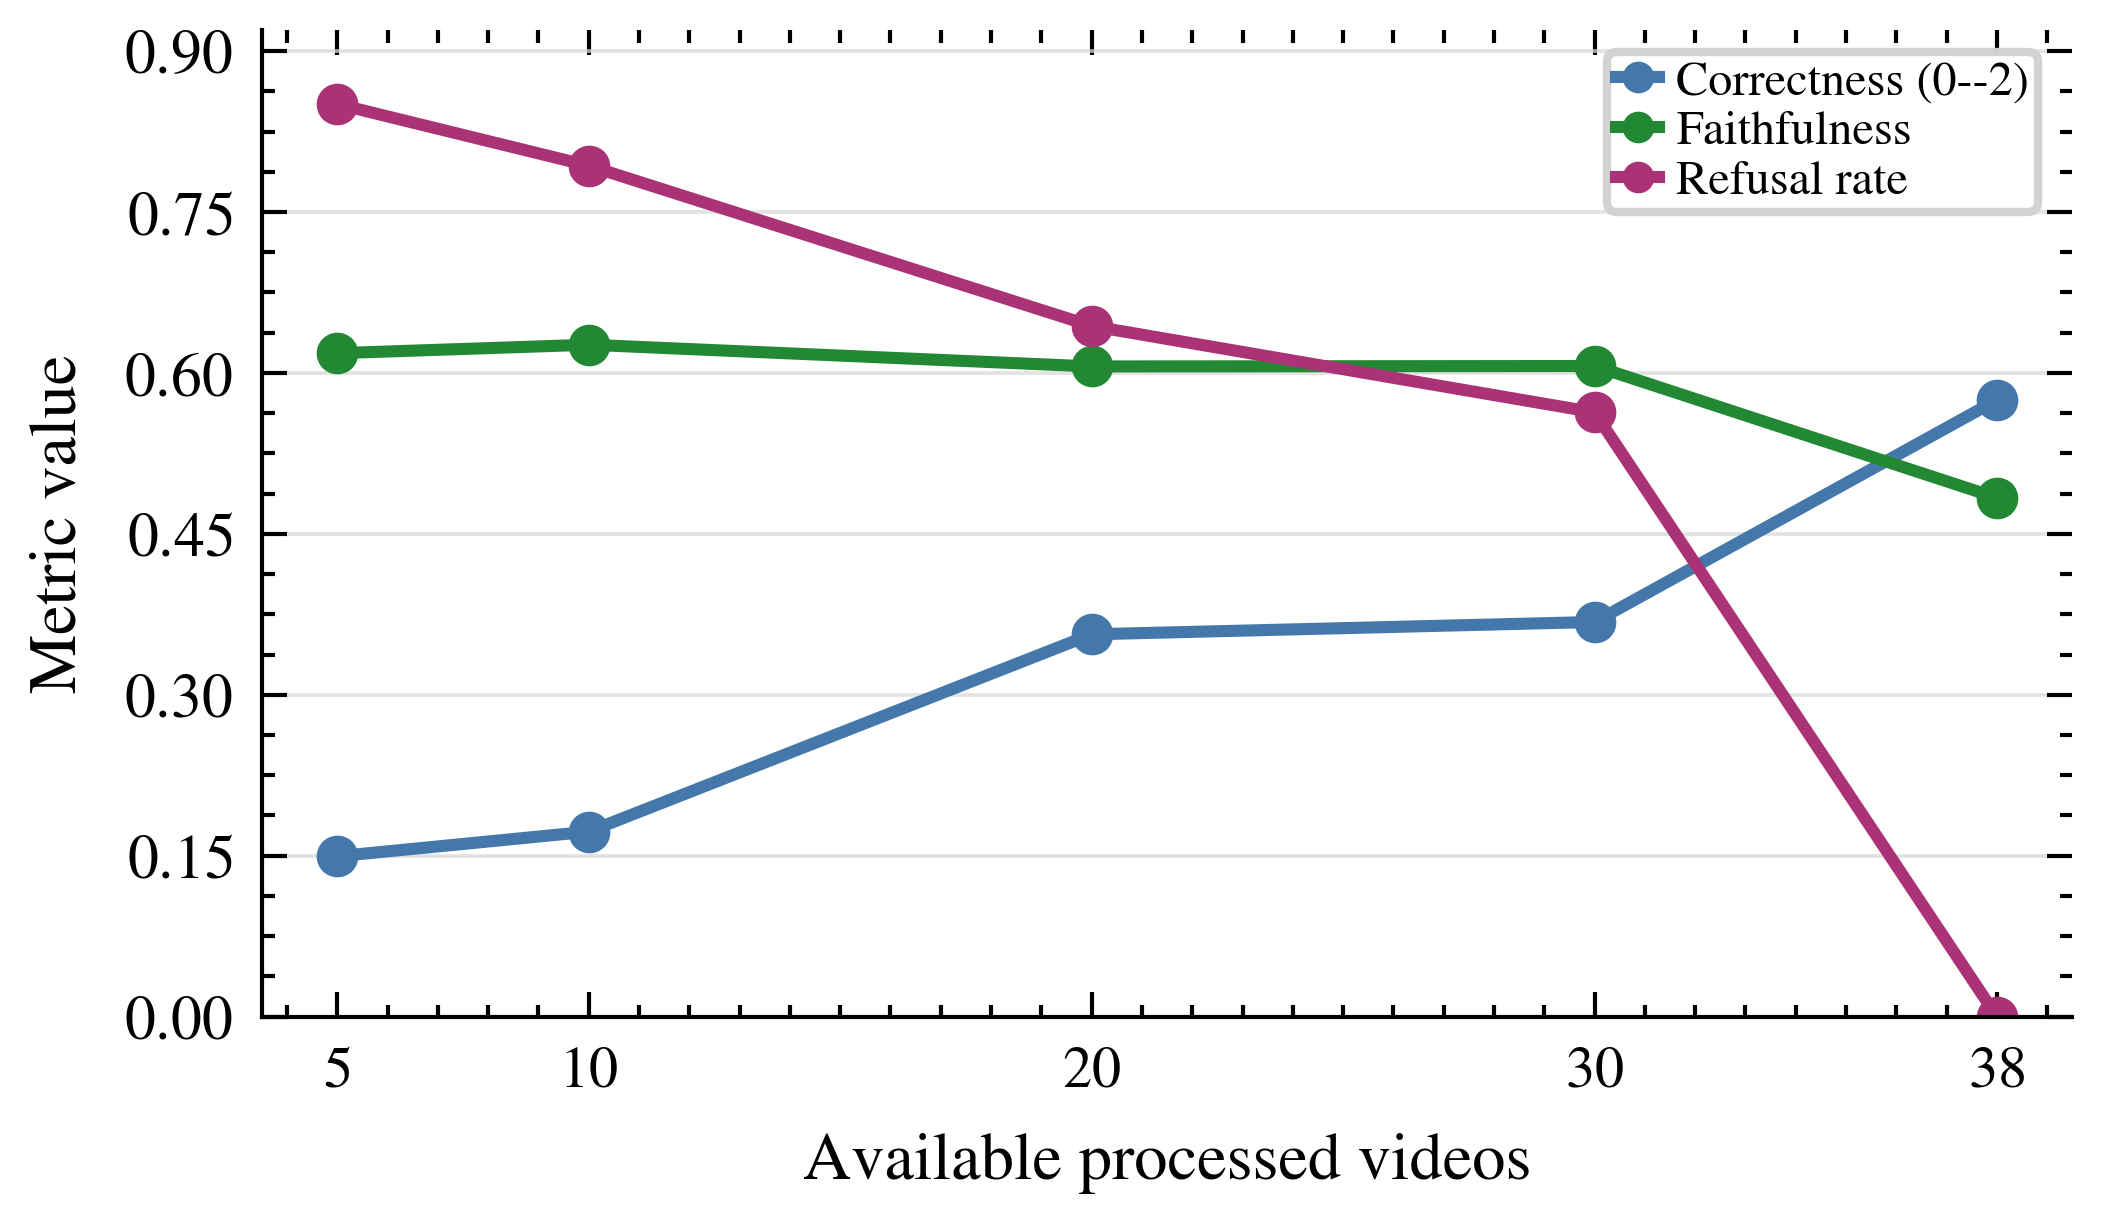

Saved PNG export to /home/gatv-projects/Desktop/project/knowledge_system_evaluation_v2/paper_v2_development/figure_14_corpus_size_scaling_original_endpoint.png
Saved PDF export to /home/gatv-projects/Desktop/project/knowledge_system_evaluation_v2/paper_v2_development/figure_14_corpus_size_scaling_original_endpoint.pdf


In [ ]:
from pathlib import Path
import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

# Figure 14 — Alternate corpus-size scaling view.
# 5/10/20/30 values come from the Phase 8 fresh scaling rerun.
# The 38-video endpoint uses the earlier original full-corpus Graph-RAG non-refusal subset metrics.
plt.style.use(["science", "ieee", "no-latex", "bright"])
mpl.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.titleweight": "semibold",
    "xtick.labelsize": 7,
    "ytick.labelsize": 7.4,
    "legend.fontsize": 6.8,
    "savefig.dpi": 600,
})
BRIGHT = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

summary_path = Path("knowledge_system_evaluation_v2/phase_8/graph_rag_corpus_scaling_summary.csv")
if not summary_path.exists():
    summary_path = Path("../phase_8/graph_rag_corpus_scaling_summary.csv")

rows = []
with summary_path.open(encoding="utf-8") as file:
    reader = csv.DictReader(file)
    for row in reader:
        rows.append(row)

# Use Phase 8 rerun values for 5/10/20/30.
phase8_rows = [row for row in rows if int(row["num_videos"]) < 38]
num_videos = np.array([int(row["num_videos"]) for row in phase8_rows] + [38], dtype=float)
correctness = np.array([float(row["mean_correctness"]) for row in phase8_rows] + [0.5747126436781609], dtype=float)
faithfulness = np.array([float(row["mean_faithfulness"]) for row in phase8_rows] + [0.4836], dtype=float)
refusal = np.array([float(row["refusal_rate"]) for row in phase8_rows] + [0.0], dtype=float)

fig, ax = plt.subplots(figsize=(3.55, 2.35), facecolor="white")

ax.plot(
    num_videos,
    correctness,
    color=BRIGHT[0],
    marker="o",
    markersize=4.0,
    linewidth=1.45,
    label="Correctness (0--2)",
)
ax.plot(
    num_videos,
    faithfulness,
    color=BRIGHT[2],
    marker="o",
    markersize=4.0,
    linewidth=1.45,
    label="Faithfulness",
)
ax.plot(
    num_videos,
    refusal,
    color=BRIGHT[5],
    marker="o",
    markersize=4.0,
    linewidth=1.45,
    label="Refusal rate",
)

ax.set_xlabel("Available processed videos")
ax.set_ylabel("Metric value")
ax.set_xticks(num_videos.astype(int))
ax.set_xlim(num_videos.min() - 1.5, num_videos.max() + 1.5)
ax.set_ylim(0.0, 0.92)
ax.set_yticks(np.arange(0.0, 0.91, 0.15))
ax.grid(axis="y", color="#D9D9D9", linewidth=0.45, alpha=0.75)
ax.grid(axis="x", visible=False)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(0.985, 0.985),
    frameon=True,
    facecolor="white",
    edgecolor="#D0D0D0",
    framealpha=0.95,
    fontsize=5.8,
    handlelength=0.9,
    handletextpad=0.35,
    borderpad=0.18,
    labelspacing=0.12,
    borderaxespad=0.15,
    markerscale=0.7,
)

# fig.text(
#     0.02,
#     0.055,
#     "5--30 video points are Phase 8 reruns; 38-video endpoint uses the original full-corpus Graph-RAG non-refusal subset metrics (n = 87).",
#     ha="left",
#     va="center",
#     fontsize=5.65,nswer quality
#     color="#4D4D4D",
# )

fig.subplots_adjust(left=0.14, right=0.99, top=0.94, bottom=0.24)

output_dir = Path.cwd()
if output_dir.name != "paper_v2_development":
    output_dir = Path("knowledge_system_evaluation_v2/paper_v2_development")
output_dir.mkdir(parents=True, exist_ok=True)
output_path_png = output_dir / "figure_14_corpus_size_scaling_original_endpoint.png"
output_path_pdf = output_dir / "figure_14_corpus_size_scaling_original_endpoint.pdf"
fig.savefig(output_path_png, dpi=600, bbox_inches="tight", facecolor="white", transparent=False)
fig.savefig(output_path_pdf, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print(f"Saved PNG export to {output_path_png.resolve()}")
print(f"Saved PDF export to {output_path_pdf.resolve()}")


In [ ]:
# Figure — Corpus-Covered Subset Metrics Heatmap Without Footer
from pathlib import Path
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Rectangle

try:
    import scienceplots  # noqa: F401
    plt.style.use(["science", "ieee", "no-latex", "bright"])
except Exception:
    pass

mpl.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 10,
    "axes.titleweight": "semibold",
    "xtick.labelsize": 7.4,
    "ytick.labelsize": 7.4,
    "savefig.dpi": 600,
})

systems = [
    "Vanilla base",
    "SOTA base",
    "BM25",
    "ASR-only RAG",
    "Vision-only RAG",
    "Vector-only RAG",
    "Graph-RAG",
]
quality_cols = ["Correctness\n(0-2)", "Faithfulness"]
quality = np.array([
    [0.862, np.nan],
    [1.310, np.nan],
    [0.368, 0.604],
    [0.368, 0.589],
    [0.414, 0.611],
    [0.460, 0.593],
    [0.575, 0.484],
], dtype=float)
refusal = np.array([0.011, 0.000, 0.552, 0.540, 0.506, 0.437, 0.000], dtype=float)

blue = LinearSegmentedColormap.from_list("paper_blue", ["#F1F7FC", "#9DBBD7", "#4E83B2"])
magenta = LinearSegmentedColormap.from_list("paper_magenta", ["#FFF7FC", "#D8A9C7", "#B22D7E"])
gray = "#D9D9D9"
graph_green = "#1F9A45"

fig = plt.figure(figsize=(7.16, 3.05), facecolor="white")
gs = fig.add_gridspec(1, 2, width_ratios=[2.0, 1.0], wspace=0.06)
ax_q = fig.add_subplot(gs[0, 0])
ax_r = fig.add_subplot(gs[0, 1])

def draw_panel(ax, data, col_labels, cmap, norm, fmt, is_percent=False):
    n_rows, n_cols = data.shape
    ax.set_xlim(0, n_cols)
    ax.set_ylim(n_rows, -1.15)
    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_xticklabels(col_labels)
    ax.xaxis.tick_top()
    ax.tick_params(axis="x", length=0, pad=8)
    ax.set_yticks(np.arange(n_rows) + 0.5)
    ax.set_yticklabels(systems)
    ax.tick_params(axis="y", length=0, pad=5)
    for spine in ax.spines.values():
        spine.set_visible(False)

    for r in range(n_rows):
        for c in range(n_cols):
            value = data[r, c]
            if np.isnan(value):
                face = gray
                label = "N/A"
                text_color = "#4D4D4D"
            else:
                face = cmap(norm(value))
                label = f"{100 * value:.1f}%" if is_percent else fmt.format(value)
                rgba = mpl.colors.to_rgba(face)
                luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
                text_color = "white" if luminance < 0.70 else "#202020"
            ax.add_patch(Rectangle((c, r), 1, 1, facecolor=face, edgecolor="white", linewidth=1.2))
            ax.text(c + 0.5, r + 0.5, label, ha="center", va="center", fontsize=7.6, fontweight="semibold", color=text_color)

    ax.hlines(2, 0, n_cols, colors="#9B9B9B", linewidth=1.0)
    ax.add_patch(Rectangle((0, 6), n_cols, 1, facecolor="none", edgecolor=graph_green, linewidth=1.05))
    labels = ax.get_yticklabels()
    labels[-1].set_color(graph_green)
    labels[-1].set_fontweight("semibold")

draw_panel(ax_q, quality, quality_cols, blue, Normalize(0.35, 1.35), "{:.3f}")
draw_panel(ax_r, refusal[:, None], ["Refusal\nrate"], magenta, Normalize(0.0, 0.56), "{:.3f}", is_percent=True)
ax_r.set_yticklabels([])

ax_q.set_title("(a) Answer quality on corpus-covered subset", pad=26)
ax_r.set_title("(b) Refusal behavior", pad=26)
fig.subplots_adjust(left=0.12, right=0.995, top=0.78, bottom=0.06)

output_dir = Path.cwd()
if output_dir.name != "paper_v2_development":
    output_dir = Path("knowledge_system_evaluation_v2/paper_v2_development")
output_png = output_dir / "figure_subset_metrics_graph_rag_answered_heatmap.png"
output_pdf = output_dir / "figure_subset_metrics_graph_rag_answered_heatmap.pdf"
fig.savefig(output_png, bbox_inches="tight", facecolor="white", transparent=False)
fig.savefig(output_pdf, bbox_inches="tight", facecolor="white", transparent=False)
plt.show()
print(f"Saved PNG export to {output_png.resolve()}")
print(f"Saved PDF export to {output_pdf.resolve()}")
